<a href="https://colab.research.google.com/github/phungngocbich/phungngocbich.com/blob/code_model_nckh/LSTMmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# XỬ LÝ DỮ LIỆU
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore

In [ ]:
# Đọc dữ liệu từ file CSV
file_path = '/content/drive/MyDrive/NCKH/DATA/trends_filtered_2020_2025.csv'
data = pd.read_csv(file_path)

# Xử lý giá trị ngoại lai (outliers)
z_scores = zscore(data['Interest_Over_Time'])
outliers = np.abs(z_scores) > 3  # Loại bỏ các điểm có z-score > 3
data_cleaned = data[~outliers]

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
data_cleaned['Interest_Over_Time'] = scaler.fit_transform(data_cleaned[['Interest_Over_Time']])

In [ ]:
# Chia dữ liệu thành các tập khác nhau dựa trên cột 'Keyword'
keywords = data_cleaned['Keyword'].unique()
keyword_dataframes = {keyword: data_cleaned[data_cleaned['Keyword'] == keyword] for keyword in keywords}

In [ ]:
# Hàm áp dụng kỹ thuật Sliding Window
def apply_sliding_window(df, window_size, step_size):
    windows = []
    for i in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[i:i + window_size]
        windows.append(window)
    return windows

In [ ]:
# Kích thước cửa sổ và bước dịch chuyển
window_size = 15  # Ví dụ: cửa sổ 15 tuần
step_size = 5  # Dịch chuyển 5 tuần mỗi lần

In [ ]:
# Áp dụng Sliding Window cho từng tập dữ liệu của từng keyword
sliding_windows = {}
for keyword, df in keyword_dataframes.items():
    windows = apply_sliding_window(df, window_size, step_size)
    sliding_windows[keyword] = windows

In [ ]:
# CHIA DỮ LIỆU VÀ XÂY DỰNG MÔ HÌNH
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# In kết quả Sliding Window cho từng keyword
for keyword, windows in sliding_windows.items():
    print(f"Keyword: {keyword}")
    print(f"Số lượng window: {len(windows)}")
    for i, window in enumerate(windows):
        print(f"Window {i + 1}:")
        print(window)
        print("\n")

NameError: name 'sliding_windows' is not defined

In [ ]:
# Hàm chuẩn bị dữ liệu cho LSTM
def prepare_data_for_lstm(windows, n_steps_in, n_steps_out):
    X, y = [], []
    for window in windows:
        # Kiểm tra xem window có phải là DataFrame không
        if isinstance(window, pd.DataFrame):
            # Lấy giá trị 'Search Interest' làm features
            features = window['Interest_Over_Time'].values
        elif isinstance(window, np.ndarray):
            # Nếu window là NumPy array, giả sử cột 'Interest_Over_Time' là cột cuối cùng
            features = window[:, -1]  # Lấy cột cuối cùng làm features
        else:
            raise TypeError(f"Unexpected window type: {type(window)}")

        # Tạo các chuỗi dữ liệu với n_steps_in bước thời gian và n_steps_out giá trị dự đoán
        for i in range(len(features) - n_steps_in - n_steps_out + 1):
            X.append(features[i:i + n_steps_in])
            y.append(features[i + n_steps_in:i + n_steps_in + n_steps_out])
    return np.array(X), np.array(y)

In [ ]:
# Hàm tính các chỉ số đánh giá (cải tiến để xử lý giá trị gần 0)
def evaluate_model(y_true, y_pred):
    epsilon = 1e-10  # Giá trị nhỏ để tránh chia cho 0
    y_true = np.maximum(y_true, epsilon)  # Đảm bảo không có giá trị 0
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, mape, rmse, r2

In [ ]:
# Áp dụng cho từng keyword
n_steps_in = 1  # Số bước thời gian đầu vào (timesteps)
n_steps_out = 1  # Số giá trị dự đoán đầu ra
epochs = 50  # Số epochs
batch_size = 16  # Batch size
optimizer = 'adam'  # Optimizer
loss = 'mse'  # Loss function

In [ ]:
# Hàm xây dựng mô hình LSTM (cải tiến để tránh overfitting)
def build_lstm_model(input_shape, n_steps_out, optimizer=optimizer, loss=loss):
    model = Sequential()
    model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))  # Thêm Dropout để tránh overfitting
    model.add(LSTM(50, activation='relu'))
    model.add(Dropout(0.2))  # Thêm Dropout để tránh overfitting
    model.add(Dense(n_steps_out, activation='sigmoid'))  # Sử dụng sigmoid để đầu ra nằm trong [0, 1]
    model.compile(optimizer=optimizer, loss=loss, metrics=['mae'])
    return model

In [ ]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra (tỉ lệ 8:2 theo thời gian)
def split_train_test_fixed(windows, train_ratio=0.8):
    train_windows, test_windows = [], []

    # Sắp xếp tất cả các window theo thời gian (từ cũ đến mới)
    windows_sorted = sorted(windows, key=lambda x: x['date'].min())  # Sắp xếp theo thời gian bắt đầu của mỗi window
    print("All windows sorted by time:")

    # Tính toán số lượng window cho tập huấn luyện và tập kiểm tra
    total_windows = len(windows_sorted)
    train_size = int(total_windows * train_ratio)  # Số lượng window cho tập huấn luyện
    test_size = total_windows - train_size  # Số lượng window cho tập kiểm tra

    print(f"Train size: {train_size}, Test size: {test_size}")

    # Tập huấn luyện: train_size window đầu tiên (thời gian nhỏ hơn)
    train_windows = windows_sorted[:train_size]

    # Tập kiểm tra: test_size window cuối cùng (thời gian gần hiện tại nhất)
    test_windows = windows_sorted[train_size:]

    return train_windows, test_windows

# Gọi hàm và in kết quả
train_windows, test_windows = split_train_test_fixed(windows)

All windows sorted by time:
Train size: 40, Test size: 10


Processing keyword: AI Security
All windows sorted by time:
Train size: 40, Test size: 10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1181 - mae: 0.3073 - val_loss: 0.1053 - val_mae: 0.2822
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1092 - mae: 0.2932 - val_loss: 0.0930 - val_mae: 0.2610
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0926 - mae: 0.2678 - val_loss: 0.0724 - val_mae: 0.2346
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0752 - mae: 0.2452 - val_loss: 0.0460 - val_mae: 0.1968
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0520 - mae: 0.2090 - val_loss: 0.0294 - val_mae: 0.1542
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0344 - mae: 0.1695 - val_loss: 0.0205 - val_mae: 0.1273
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0238 - mae: 0.1385 - val_loss: 0.0115 - val_mae: 0.0958
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131 - mae: 0.1017 - val_loss: 0.0047 - val_mae: 0.0581
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - mae:

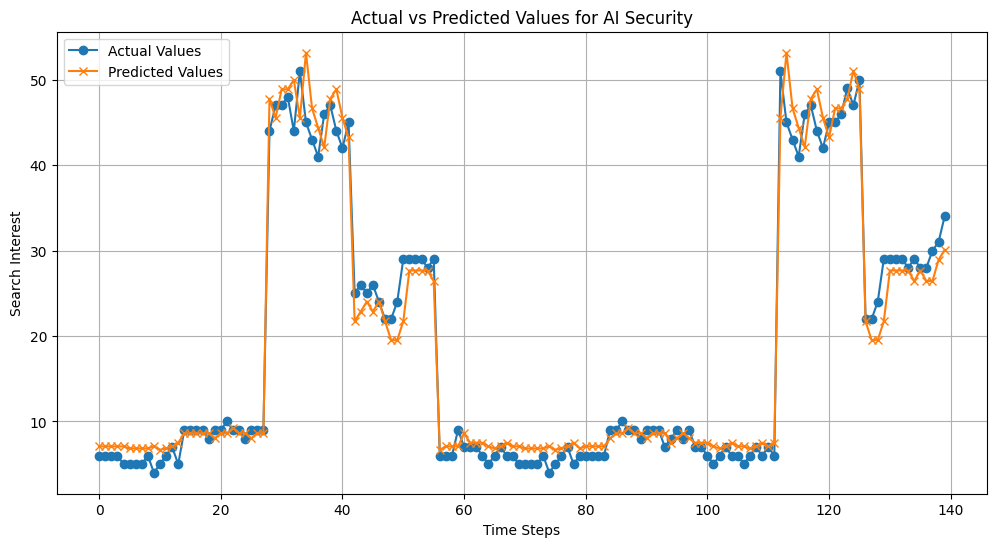

Processing keyword: AR Glasses
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0629 - mae: 0.2266 - val_loss: 0.0702 - val_mae: 0.2433
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0570 - mae: 0.2122 - val_loss: 0.0534 - val_mae: 0.2035
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0423 - mae: 0.1754 - val_loss: 0.0326 - val_mae: 0.1419
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0285 - mae: 0.1366 - val_loss: 0.0245 - val_mae: 0.1161
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0212 - mae: 0.1219 - val_loss: 0.0231 - val_mae: 0.1118
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0206 - mae: 0.1140 - val_loss: 0.0218 - val_mae: 0.1074
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0196 - mae: 0.1142 - val_loss: 0.0208 - val_mae: 0.1039
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0182 - mae: 0.1079 - val_loss: 0.0191 - val_mae: 0.0976
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0153 - mae: 0.0976 - v

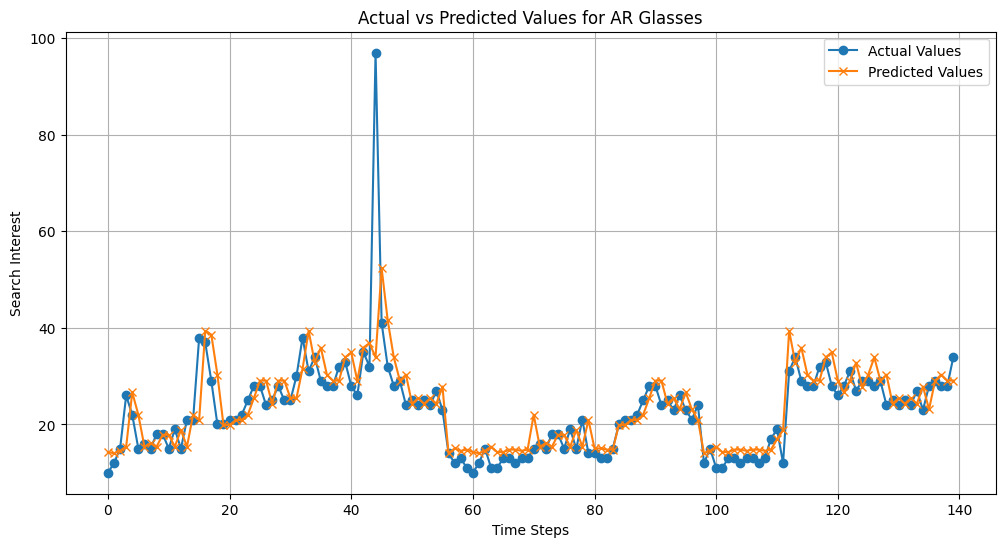

Processing keyword: Adaptive learning
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0243 - mae: 0.1291 - val_loss: 0.0170 - val_mae: 0.1113
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0214 - mae: 0.1212 - val_loss: 0.0167 - val_mae: 0.1105
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0225 - mae: 0.1263 - val_loss: 0.0163 - val_mae: 0.1089
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0232 - mae: 0.1261 - val_loss: 0.0154 - val_mae: 0.1059
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0207 - mae: 0.1218 - val_loss: 0.0137 - val_mae: 0.0998
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0174 - mae: 0.1079 - val_loss: 0.0109 - val_mae: 0.0885
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140 - mae: 0.0968 - val_loss: 0.0090 - val_mae: 0.0779
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - mae: 0.0836 - val_loss: 0.0063 - val_mae: 0.0647
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072 - mae: 0.0694 - v

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
MAE for Adaptive learning: 4.14504838671003
MAPE for Adaptive learning: 0.10143698678985988
RMSE for Adaptive learning: 5.1601707462850985
R² for Adaptive learning: 0.8369184149557394




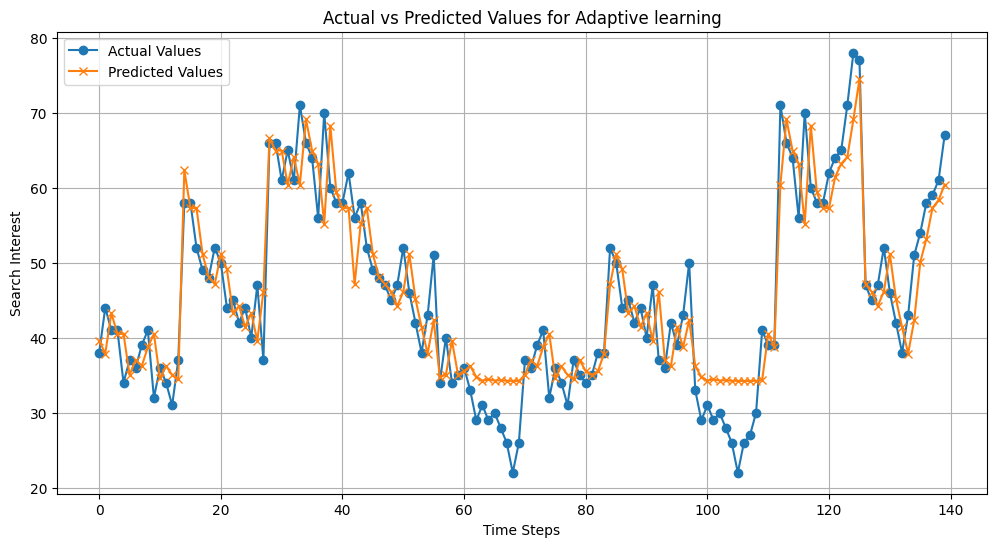

Processing keyword: Applied AI
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0586 - mae: 0.2194 - val_loss: 0.0474 - val_mae: 0.1917
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0532 - mae: 0.2106 - val_loss: 0.0355 - val_mae: 0.1703
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0432 - mae: 0.1901 - val_loss: 0.0218 - val_mae: 0.1413
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0317 - mae: 0.1538 - val_loss: 0.0155 - val_mae: 0.1144
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0240 - mae: 0.1297 - val_loss: 0.0144 - val_mae: 0.1101
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0232 - mae: 0.1281 - val_loss: 0.0128 - val_mae: 0.1019
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0265 - mae: 0.1320 - val_loss: 0.0113 - val_mae: 0.0952
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0204 - mae: 0.1175 - val_loss: 0.0096 - val_mae: 0.0885
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0178 - mae: 0.1098 - v

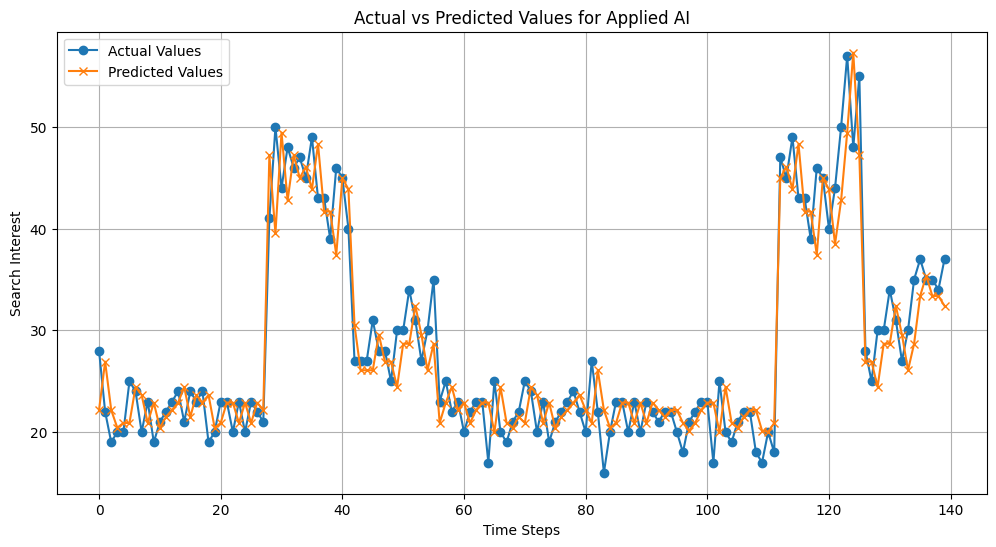

Processing keyword: Augmented reality
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0191 - mae: 0.1176 - val_loss: 0.0159 - val_mae: 0.0936
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140 - mae: 0.0952 - val_loss: 0.0088 - val_mae: 0.0584
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 - mae: 0.0622 - val_loss: 0.0072 - val_mae: 0.0633
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - mae: 0.0647 - val_loss: 0.0070 - val_mae: 0.0599
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - mae: 0.0612 - val_loss: 0.0070 - val_mae: 0.0608
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - mae: 0.0582 - val_loss: 0.0069 - val_mae: 0.0606
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - mae: 0.0568 - val_loss: 0.0069 - val_mae: 0.0591
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - mae: 0.0611 - val_loss: 0.0068 - val_mae: 0.0594
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - mae: 0.0598 - v

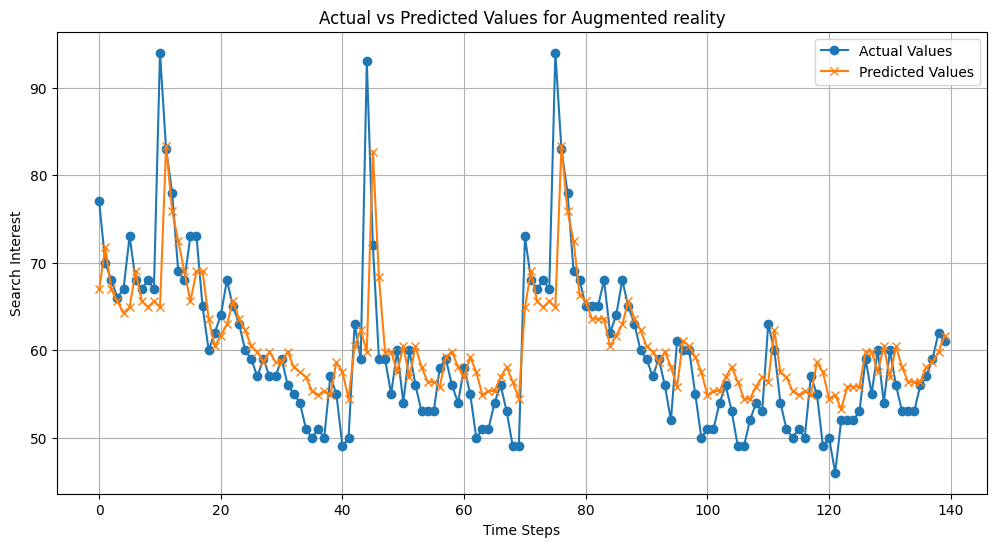

Processing keyword: Bioprinting
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0161 - mae: 0.1018 - val_loss: 0.0101 - val_mae: 0.0800
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0166 - mae: 0.1064 - val_loss: 0.0099 - val_mae: 0.0795
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154 - mae: 0.1028 - val_loss: 0.0096 - val_mae: 0.0783
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0158 - mae: 0.1003 - val_loss: 0.0094 - val_mae: 0.0776
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0148 - mae: 0.0992 - val_loss: 0.0090 - val_mae: 0.0761
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 - mae: 0.1050 - val_loss: 0.0084 - val_mae: 0.0736
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0142 - mae: 0.0943 - val_loss: 0.0077 - val_mae: 0.0704
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0128 - mae: 0.0905 - val_loss: 0.0068 - val_mae: 0.0662
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0125 - mae: 0.0903 - 

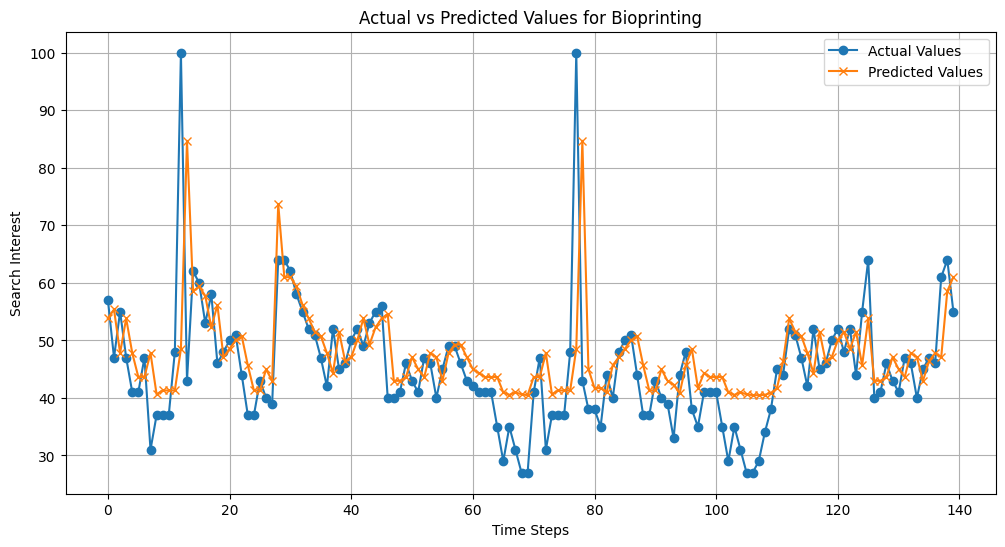

Processing keyword: CRISPR
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0190 - mae: 0.1216 - val_loss: 0.0111 - val_mae: 0.0927
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0157 - mae: 0.1069 - val_loss: 0.0063 - val_mae: 0.0659
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0104 - mae: 0.0801 - val_loss: 0.0035 - val_mae: 0.0465
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - mae: 0.0657 - val_loss: 0.0035 - val_mae: 0.0463
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - mae: 0.0602 - val_loss: 0.0035 - val_mae: 0.0460
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - mae: 0.0696 - val_loss: 0.0034 - val_mae: 0.0457
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - mae: 0.0669 - val_loss: 0.0034 - val_mae: 0.0455
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0072 - mae: 0.0604 - val_loss: 0.0034 - val_mae: 0.0453
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 - mae: 0.0618 - v

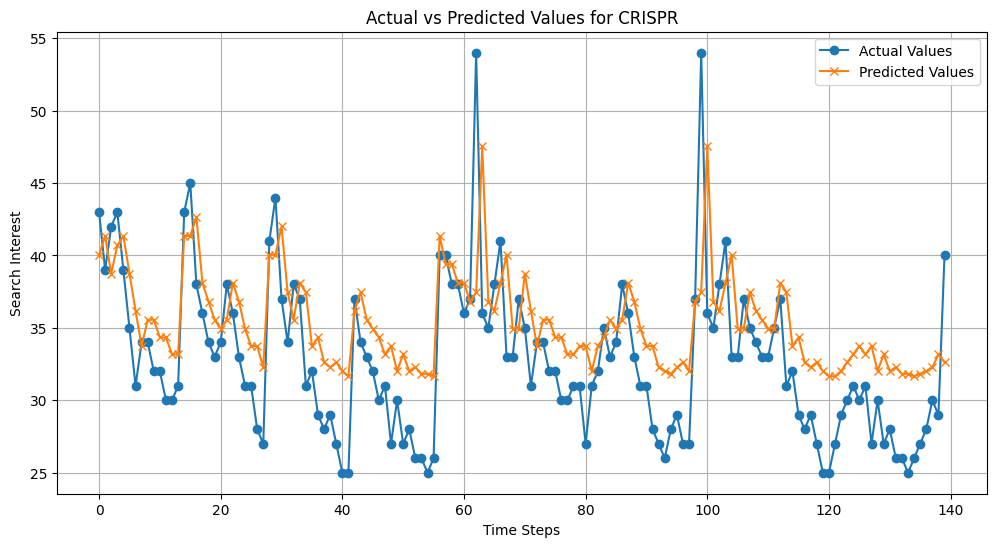

Processing keyword: Carbon Capture
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1015 - mae: 0.3127 - val_loss: 0.0972 - val_mae: 0.3074
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0834 - mae: 0.2808 - val_loss: 0.0753 - val_mae: 0.2693
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0615 - mae: 0.2399 - val_loss: 0.0391 - val_mae: 0.1895
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0280 - mae: 0.1494 - val_loss: 0.0093 - val_mae: 0.0751
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mae: 0.0703 - val_loss: 0.0044 - val_mae: 0.0504
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133 - mae: 0.0676 - val_loss: 0.0042 - val_mae: 0.0499
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0114 - mae: 0.0619 - val_loss: 0.0046 - val_mae: 0.0500
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0167 - mae: 0.0723 - val_loss: 0.0043 - val_mae: 0.0489
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - mae: 0.0611 - v

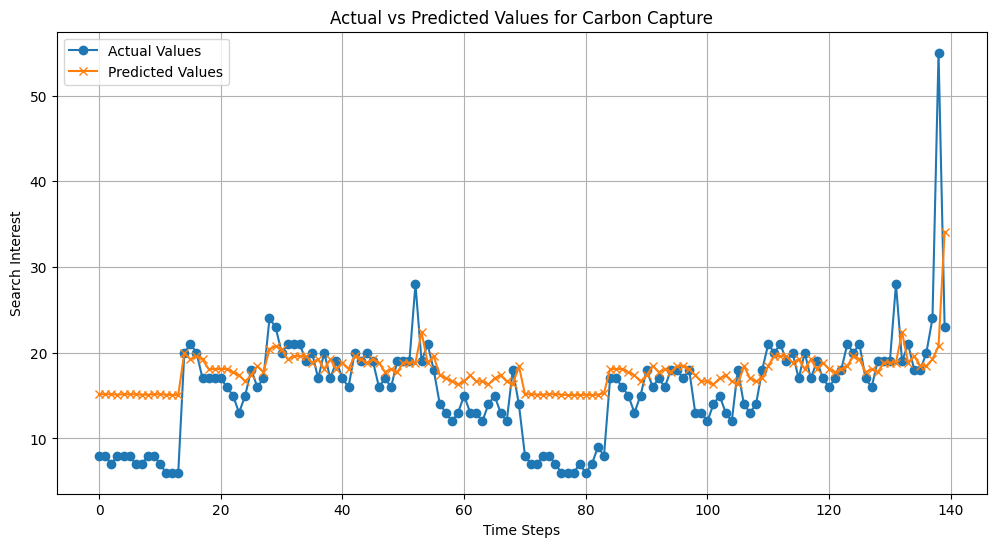

Processing keyword: Cashless Payment
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0141 - mae: 0.0967 - val_loss: 0.0103 - val_mae: 0.0819
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109 - mae: 0.0817 - val_loss: 0.0066 - val_mae: 0.0628
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - mae: 0.0695 - val_loss: 0.0053 - val_mae: 0.0586
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - mae: 0.0666 - val_loss: 0.0057 - val_mae: 0.0591
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080 - mae: 0.0678 - val_loss: 0.0054 - val_mae: 0.0586
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085 - mae: 0.0689 - val_loss: 0.0055 - val_mae: 0.0587
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082 - mae: 0.0692 - val_loss: 0.0054 - val_mae: 0.0584
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - mae: 0.0626 - val_loss: 0.0054 - val_mae: 0.0583
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 - mae: 0.0677 - v

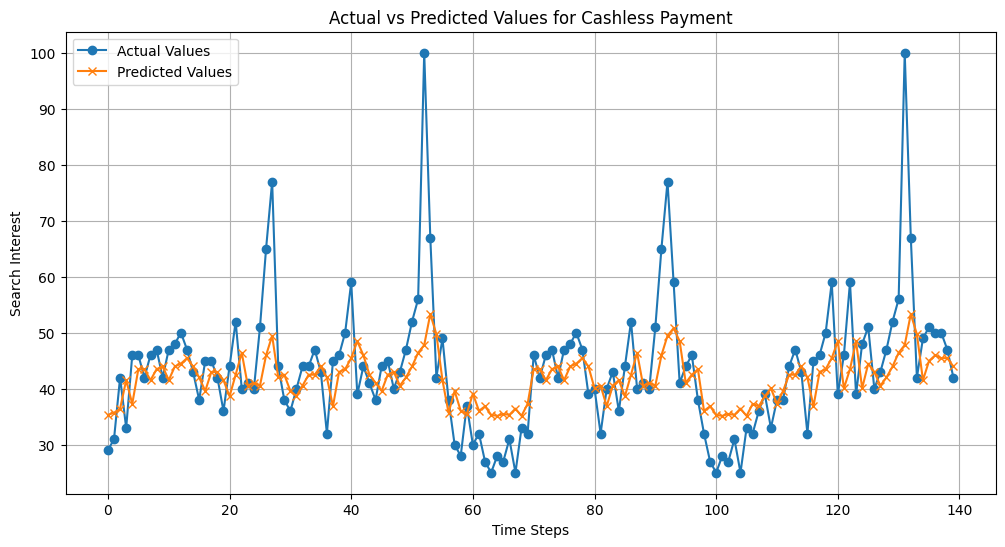

Processing keyword: Chatbots
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0376 - mae: 0.1762 - val_loss: 0.0257 - val_mae: 0.1413
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0340 - mae: 0.1698 - val_loss: 0.0233 - val_mae: 0.1378
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0325 - mae: 0.1654 - val_loss: 0.0214 - val_mae: 0.1350
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0320 - mae: 0.1642 - val_loss: 0.0196 - val_mae: 0.1305
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0268 - mae: 0.1520 - val_loss: 0.0166 - val_mae: 0.1196
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - mae: 0.1303 - val_loss: 0.0119 - val_mae: 0.1006
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0158 - mae: 0.1108 - val_loss: 0.0058 - val_mae: 0.0683
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069 - mae: 0.0717 - val_loss: 0.0019 - val_mae: 0.0373
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - mae: 0.0442 - v

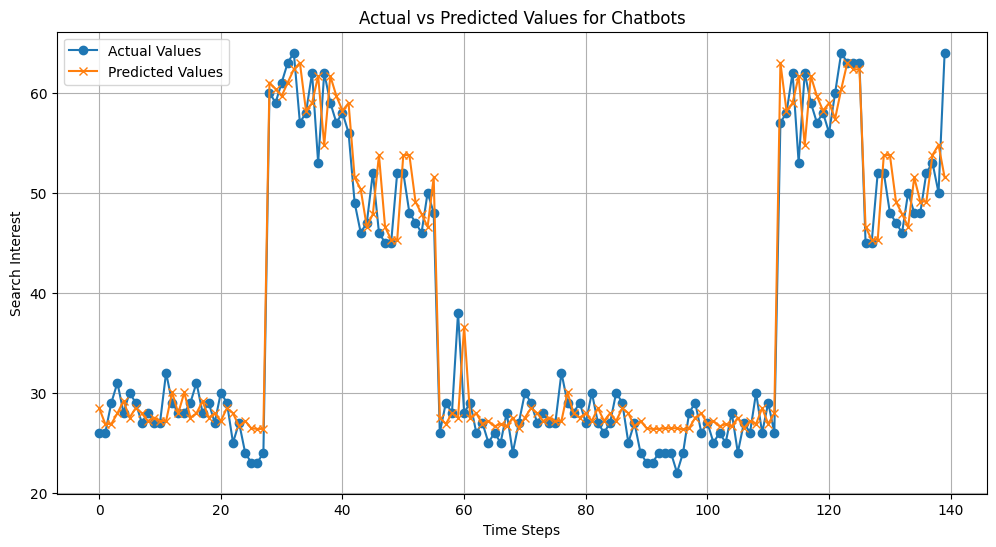

Processing keyword: Cloud computing for IoT
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0664 - mae: 0.2043 - val_loss: 0.0586 - val_mae: 0.1908
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0688 - mae: 0.2028 - val_loss: 0.0489 - val_mae: 0.1690
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0547 - mae: 0.1775 - val_loss: 0.0370 - val_mae: 0.1440
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0471 - mae: 0.1609 - val_loss: 0.0327 - val_mae: 0.1381
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0428 - mae: 0.1587 - val_loss: 0.0316 - val_mae: 0.1357
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0402 - mae: 0.1536 - val_loss: 0.0305 - val_mae: 0.1339
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0356 - mae: 0.1427 - val_loss: 0.0298 - val_mae: 0.1316
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0388 - mae: 0.1483 - val_loss: 0.0288 - val_mae: 0.1300
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0349 - mae: 0.1414 - v

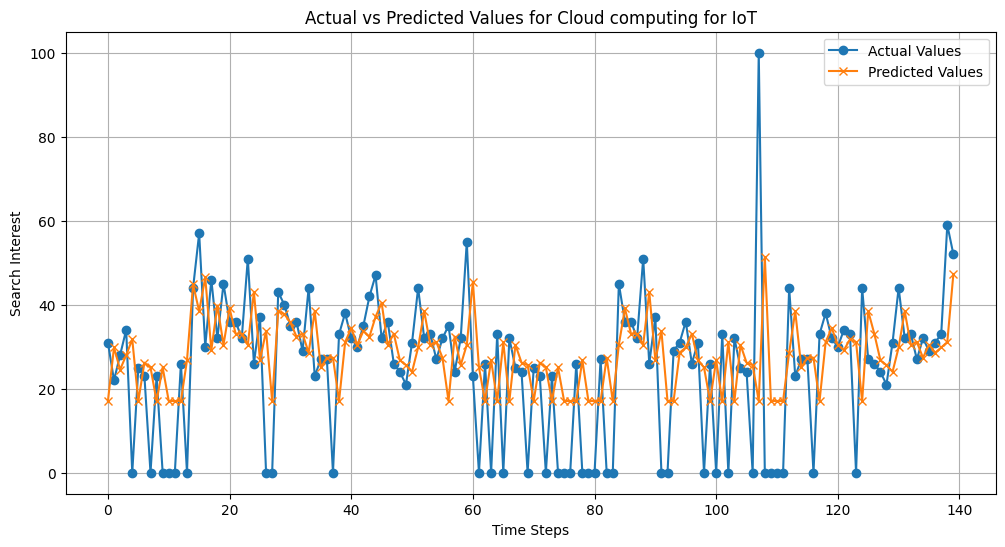

Processing keyword: Cloud computing platforms
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0324 - mae: 0.1428 - val_loss: 0.0310 - val_mae: 0.1408
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0314 - mae: 0.1386 - val_loss: 0.0315 - val_mae: 0.1421
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0257 - mae: 0.1247 - val_loss: 0.0320 - val_mae: 0.1437
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284 - mae: 0.1361 - val_loss: 0.0320 - val_mae: 0.1437
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0264 - mae: 0.1285 - val_loss: 0.0321 - val_mae: 0.1442
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0261 - mae: 0.1275 - val_loss: 0.0318 - val_mae: 0.1438
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0290 - mae: 0.1355 - val_loss: 0.0316 - val_mae: 0.1435
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0279 - mae: 0.1328 - val_loss: 0.0303 - val_mae: 0.1400
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0275 - mae: 0.1305 - v

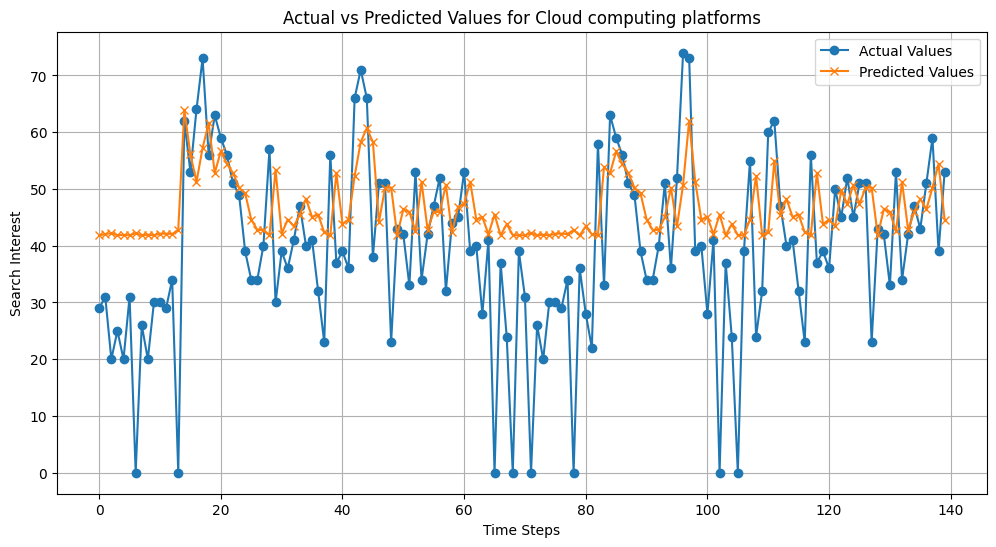

Processing keyword: Computer vision
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0630 - mae: 0.2081 - val_loss: 0.0495 - val_mae: 0.1802
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0541 - mae: 0.1932 - val_loss: 0.0369 - val_mae: 0.1624
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0352 - mae: 0.1571 - val_loss: 0.0207 - val_mae: 0.1284
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0206 - mae: 0.1260 - val_loss: 0.0191 - val_mae: 0.1146
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0191 - mae: 0.1160 - val_loss: 0.0181 - val_mae: 0.1125
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0193 - mae: 0.1176 - val_loss: 0.0175 - val_mae: 0.1100
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0177 - mae: 0.1122 - val_loss: 0.0167 - val_mae: 0.1076
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0174 - mae: 0.1104 - val_loss: 0.0156 - val_mae: 0.1045
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.1121 - v

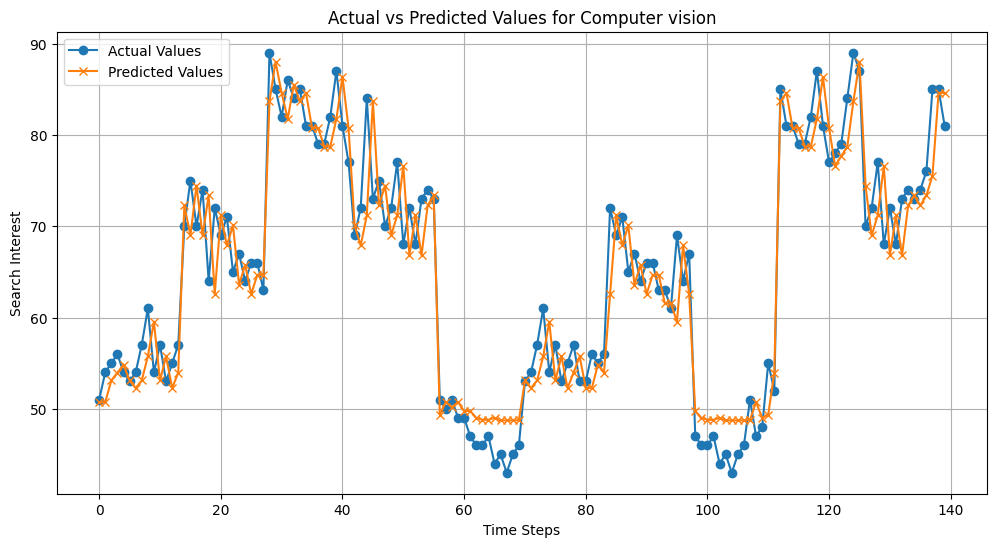

Processing keyword: Distributed Cloud
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0335 - mae: 0.1586 - val_loss: 0.0244 - val_mae: 0.1404
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0317 - mae: 0.1523 - val_loss: 0.0232 - val_mae: 0.1338
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0276 - mae: 0.1411 - val_loss: 0.0238 - val_mae: 0.1276
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0265 - mae: 0.1362 - val_loss: 0.0238 - val_mae: 0.1253
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0233 - mae: 0.1268 - val_loss: 0.0235 - val_mae: 0.1230
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0237 - mae: 0.1259 - val_loss: 0.0221 - val_mae: 0.1203
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0239 - mae: 0.1280 - val_loss: 0.0206 - val_mae: 0.1172
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0204 - mae: 0.1188 - val_loss: 0.0195 - val_mae: 0.1136
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194 - mae: 0.1156 - v

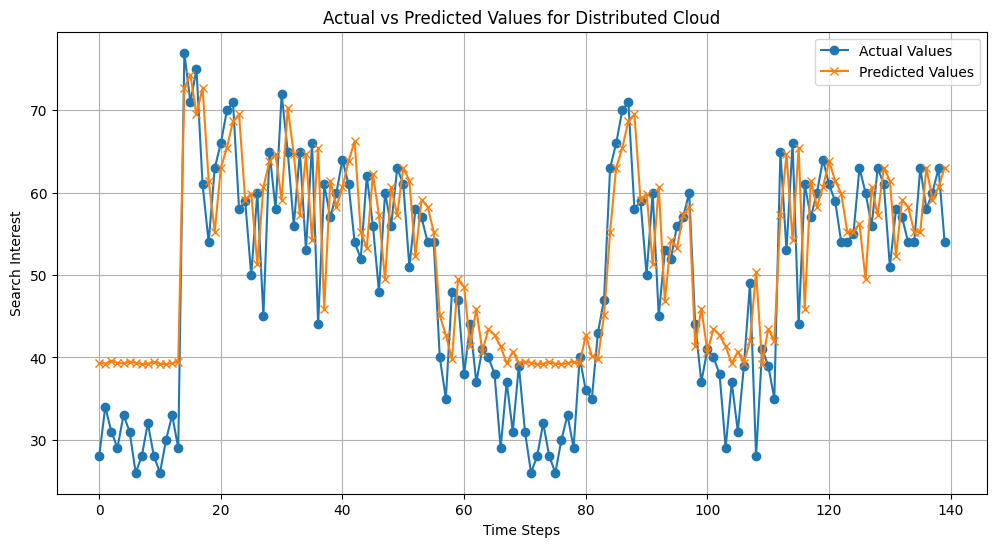

Processing keyword: Edge AI
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0934 - mae: 0.2695 - val_loss: 0.0779 - val_mae: 0.2380
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0877 - mae: 0.2653 - val_loss: 0.0675 - val_mae: 0.2224
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0741 - mae: 0.2444 - val_loss: 0.0538 - val_mae: 0.1996
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0613 - mae: 0.2283 - val_loss: 0.0390 - val_mae: 0.1765
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0434 - mae: 0.1902 - val_loss: 0.0242 - val_mae: 0.1415
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0243 - mae: 0.1428 - val_loss: 0.0100 - val_mae: 0.0884
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 - mae: 0.0887 - val_loss: 0.0032 - val_mae: 0.0495
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - mae: 0.0513 - val_loss: 0.0023 - val_mae: 0.0378
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - mae: 0.0462 - v

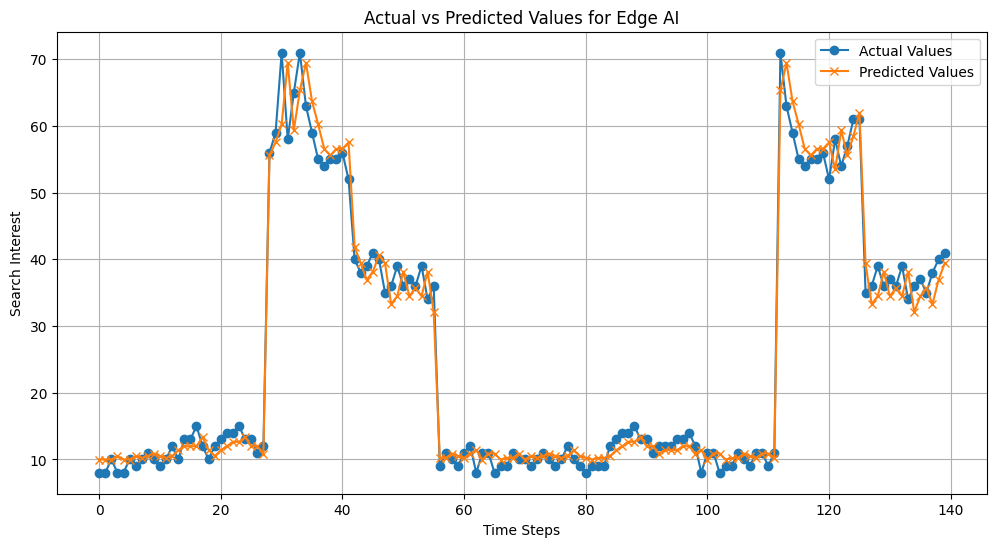

Processing keyword: FDM
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0643 - mae: 0.2316 - val_loss: 0.0473 - val_mae: 0.2012
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0521 - mae: 0.2039 - val_loss: 0.0278 - val_mae: 0.1468
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0261 - mae: 0.1349 - val_loss: 0.0063 - val_mae: 0.0653
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - mae: 0.0792 - val_loss: 0.0056 - val_mae: 0.0627
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0087 - mae: 0.0766 - val_loss: 0.0052 - val_mae: 0.0608
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0082 - mae: 0.0737 - val_loss: 0.0052 - val_mae: 0.0607
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0095 - mae: 0.0798 - val_loss: 0.0051 - val_mae: 0.0605
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0084 - mae: 0.0757 - val_loss: 0.0050 - val_mae: 0.0598
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - mae: 0.0769 - 

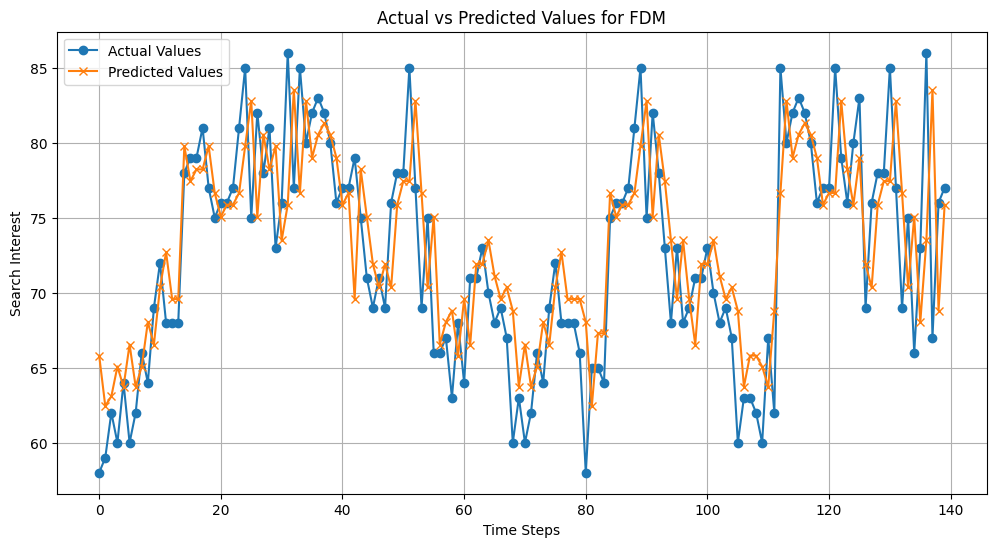

Processing keyword: Generative AI
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1790 - mae: 0.4052 - val_loss: 0.1624 - val_mae: 0.3838
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1640 - mae: 0.3871 - val_loss: 0.1506 - val_mae: 0.3699
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1492 - mae: 0.3707 - val_loss: 0.1279 - val_mae: 0.3406
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1197 - mae: 0.3307 - val_loss: 0.0890 - val_mae: 0.2815
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0815 - mae: 0.2643 - val_loss: 0.0447 - val_mae: 0.1867
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0425 - mae: 0.1827 - val_loss: 0.0190 - val_mae: 0.1131
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0187 - mae: 0.1214 - val_loss: 0.0100 - val_mae: 0.0864
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - mae: 0.0890 - val_loss: 0.0070 - val_mae: 0.0737
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080 - mae: 0.0772 - v

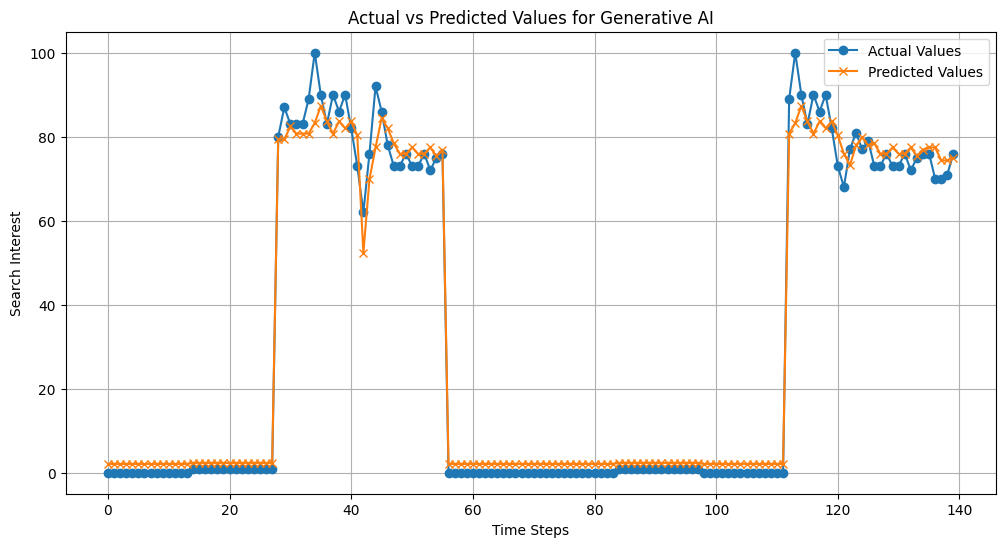

Processing keyword: Green Hydrogen
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0350 - mae: 0.1431 - val_loss: 0.0416 - val_mae: 0.1462
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0303 - mae: 0.1315 - val_loss: 0.0384 - val_mae: 0.1437
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0350 - mae: 0.1415 - val_loss: 0.0348 - val_mae: 0.1448
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0265 - mae: 0.1258 - val_loss: 0.0317 - val_mae: 0.1455
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0263 - mae: 0.1298 - val_loss: 0.0288 - val_mae: 0.1397
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0239 - mae: 0.1220 - val_loss: 0.0247 - val_mae: 0.1283
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0197 - mae: 0.1084 - val_loss: 0.0185 - val_mae: 0.1063
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0162 - mae: 0.0989 - val_loss: 0.0112 - val_mae: 0.0826
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126 - mae: 0.0811 - v

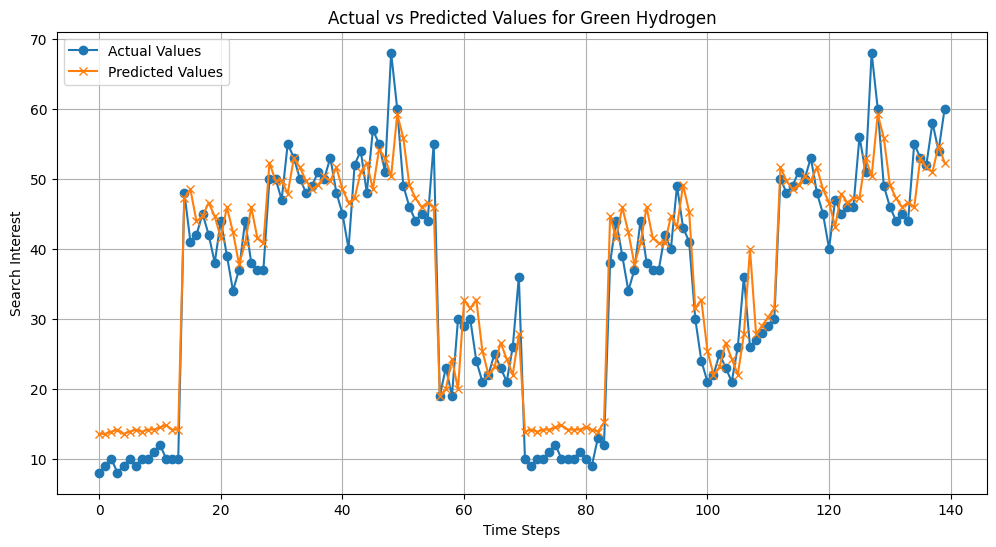

Processing keyword: Green cloud computing
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0648 - mae: 0.2058 - val_loss: 0.0765 - val_mae: 0.2200
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0612 - mae: 0.1982 - val_loss: 0.0701 - val_mae: 0.2089
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0539 - mae: 0.1829 - val_loss: 0.0629 - val_mae: 0.1968
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0567 - mae: 0.1906 - val_loss: 0.0556 - val_mae: 0.1838
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0504 - mae: 0.1771 - val_loss: 0.0495 - val_mae: 0.1718
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0480 - mae: 0.1743 - val_loss: 0.0426 - val_mae: 0.1565
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0420 - mae: 0.1615 - val_loss: 0.0350 - val_mae: 0.1374
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0359 - mae: 0.1466 - val_loss: 0.0304 - val_mae: 0.1259
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0293 - mae: 0.1331 - 

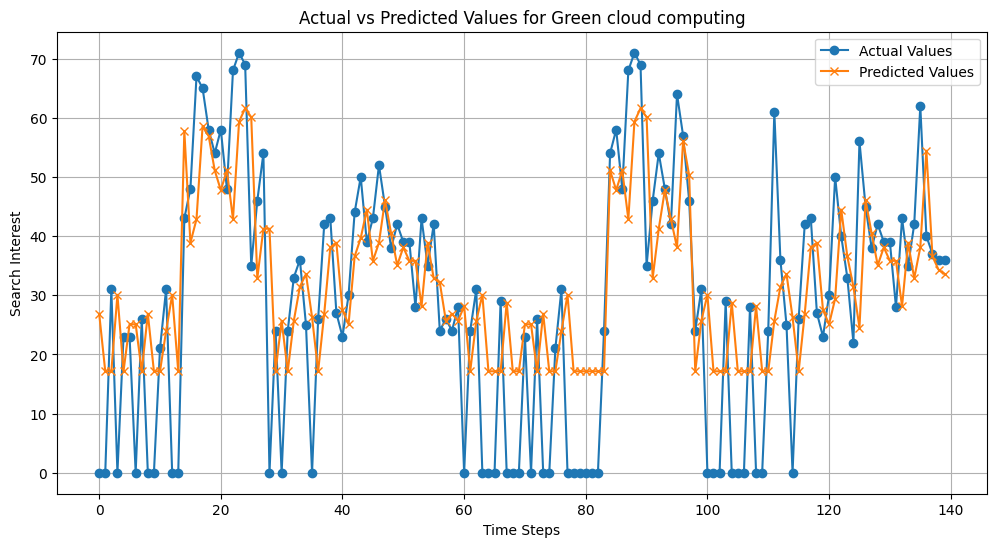

Processing keyword: Industrial Robots
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0502 - mae: 0.1917 - val_loss: 0.0295 - val_mae: 0.1430
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0381 - mae: 0.1635 - val_loss: 0.0177 - val_mae: 0.1068
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0231 - mae: 0.1271 - val_loss: 0.0124 - val_mae: 0.0883
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0202 - mae: 0.1154 - val_loss: 0.0128 - val_mae: 0.0899
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176 - mae: 0.1085 - val_loss: 0.0120 - val_mae: 0.0865
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0171 - mae: 0.1061 - val_loss: 0.0121 - val_mae: 0.0867
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0171 - mae: 0.1068 - val_loss: 0.0116 - val_mae: 0.0850
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0168 - mae: 0.1063 - val_loss: 0.0117 - val_mae: 0.0850
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.1057 - v

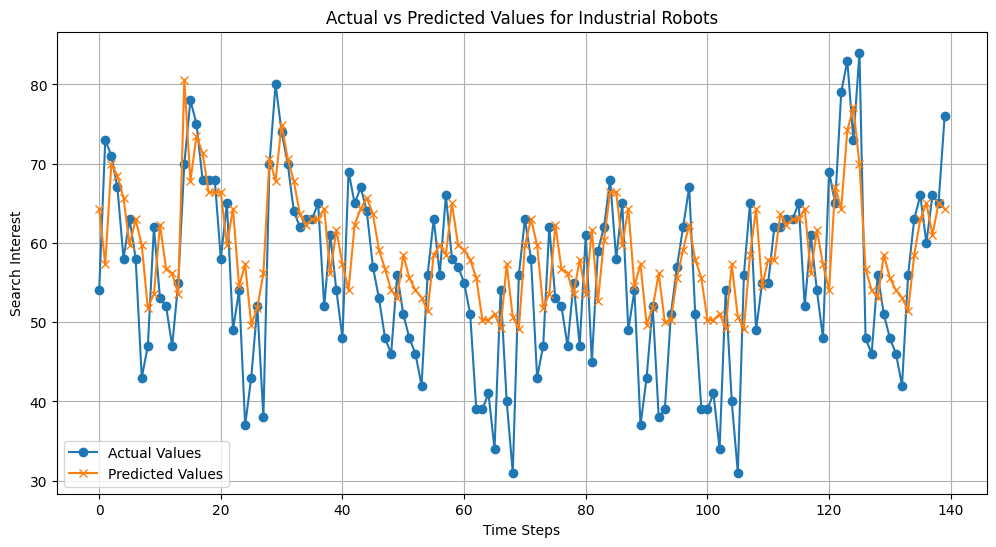

Processing keyword: IoT security and trust
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2476 - mae: 0.4973 - val_loss: 0.2401 - val_mae: 0.4899
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2369 - mae: 0.4866 - val_loss: 0.2218 - val_mae: 0.4710
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2141 - mae: 0.4616 - val_loss: 0.1904 - val_mae: 0.4362
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1768 - mae: 0.4195 - val_loss: 0.1377 - val_mae: 0.3694
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1160 - mae: 0.3382 - val_loss: 0.0698 - val_mae: 0.2532
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0499 - mae: 0.2150 - val_loss: 0.0319 - val_mae: 0.1368
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161 - mae: 0.1072 - val_loss: 0.0244 - val_mae: 0.0825
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - mae: 0.0579 - val_loss: 0.0234 - val_mae: 0.0626
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069 - mae: 0.0466 - v

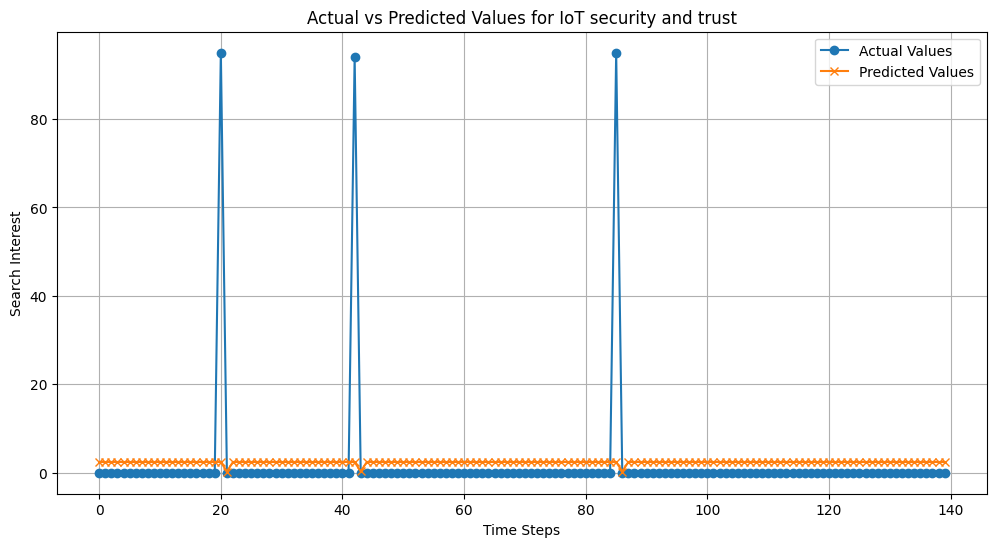

Processing keyword: Lab-grown Meat
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.2329 - mae: 0.4823 - val_loss: 0.2165 - val_mae: 0.4624
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2173 - mae: 0.4658 - val_loss: 0.1958 - val_mae: 0.4392
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1917 - mae: 0.4374 - val_loss: 0.1598 - val_mae: 0.3953
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1483 - mae: 0.3841 - val_loss: 0.1048 - val_mae: 0.3152
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0865 - mae: 0.2918 - val_loss: 0.0509 - val_mae: 0.2038
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0324 - mae: 0.1743 - val_loss: 0.0274 - val_mae: 0.1178
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0102 - mae: 0.0927 - val_loss: 0.0222 - val_mae: 0.0776
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - mae: 0.0508 - val_loss: 0.0210 - val_mae: 0.0612
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - mae: 0.0426 -

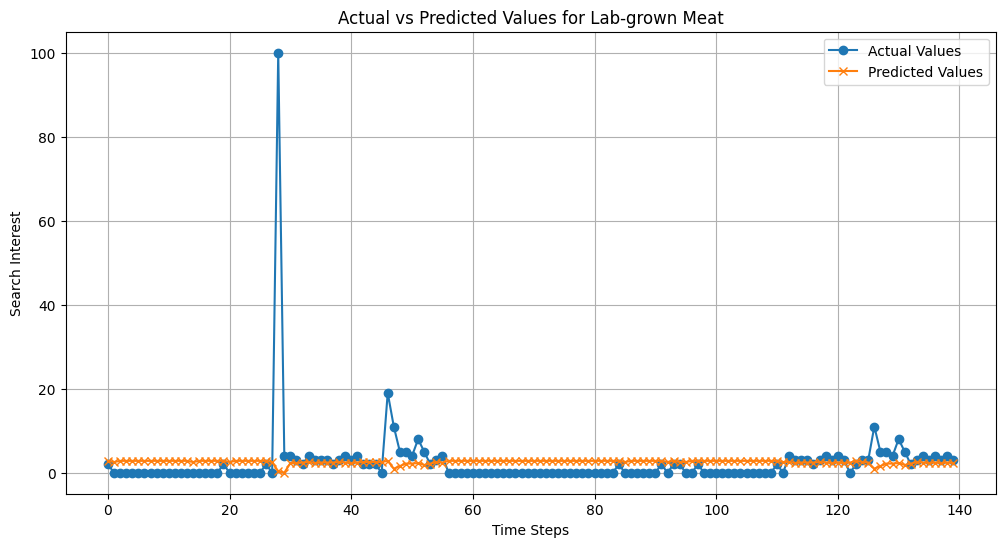

Processing keyword: LiDAR
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0093 - mae: 0.0749 - val_loss: 0.0043 - val_mae: 0.0539
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - mae: 0.0655 - val_loss: 0.0027 - val_mae: 0.0444
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - mae: 0.0521 - val_loss: 0.0024 - val_mae: 0.0407
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0047 - mae: 0.0523 - val_loss: 0.0024 - val_mae: 0.0405
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0507 - val_loss: 0.0023 - val_mae: 0.0404
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - mae: 0.0560 - val_loss: 0.0023 - val_mae: 0.0403
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0057 - mae: 0.0531 - val_loss: 0.0023 - val_mae: 0.0401
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0046 - mae: 0.0531 - val_loss: 0.0023 - val_mae: 0.0400
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - mae: 0.0529 -

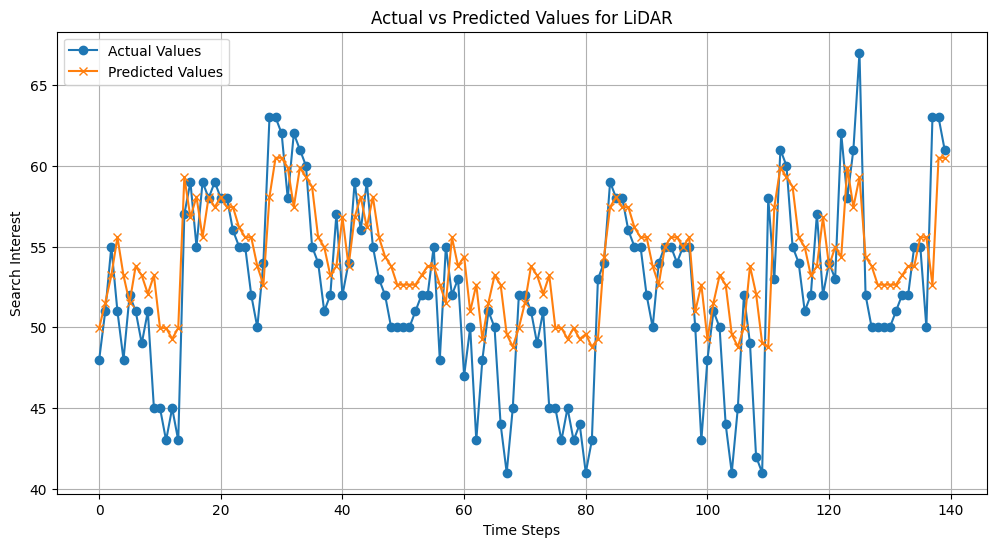

Processing keyword: Metaverse
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1572 - mae: 0.3784 - val_loss: 0.1694 - val_mae: 0.4004
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1539 - mae: 0.3789 - val_loss: 0.1507 - val_mae: 0.3763
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1358 - mae: 0.3546 - val_loss: 0.1200 - val_mae: 0.3336
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1074 - mae: 0.3062 - val_loss: 0.0768 - val_mae: 0.2639
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0707 - mae: 0.2421 - val_loss: 0.0352 - val_mae: 0.1778
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0468 - mae: 0.1848 - val_loss: 0.0142 - val_mae: 0.1122
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0236 - mae: 0.1268 - val_loss: 0.0059 - val_mae: 0.0717
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - mae: 0.0805 - val_loss: 0.0032 - val_mae: 0.0509
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - mae: 0.0634 - v

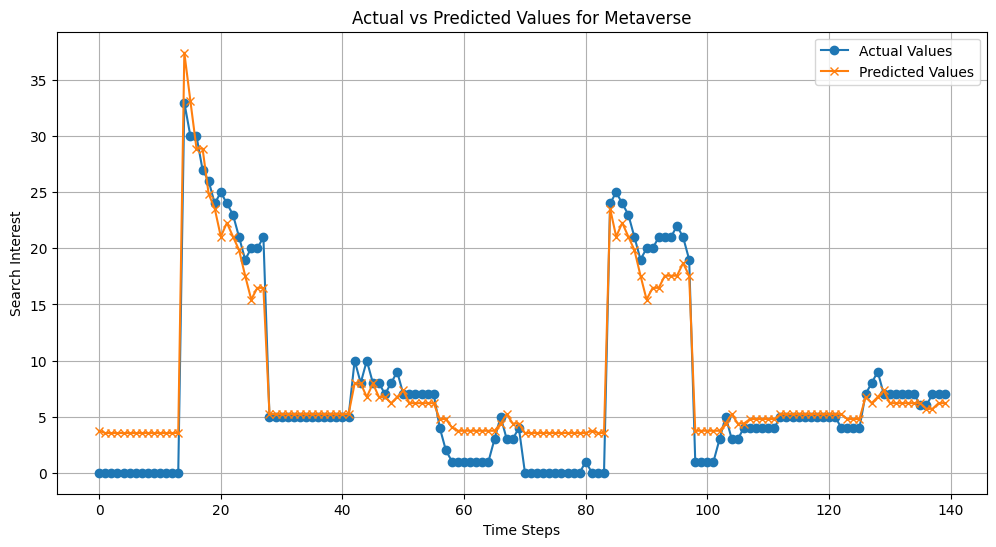

Processing keyword: NFT
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1580 - mae: 0.3790 - val_loss: 0.1542 - val_mae: 0.3804
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1502 - mae: 0.3695 - val_loss: 0.1340 - val_mae: 0.3526
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1312 - mae: 0.3433 - val_loss: 0.0996 - val_mae: 0.3006
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0972 - mae: 0.2891 - val_loss: 0.0544 - val_mae: 0.2215
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0644 - mae: 0.2297 - val_loss: 0.0230 - val_mae: 0.1413
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0392 - mae: 0.1630 - val_loss: 0.0121 - val_mae: 0.1015
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0291 - mae: 0.1307 - val_loss: 0.0080 - val_mae: 0.0826
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0158 - mae: 0.1010 - val_loss: 0.0043 - val_mae: 0.0602
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - mae: 0.072

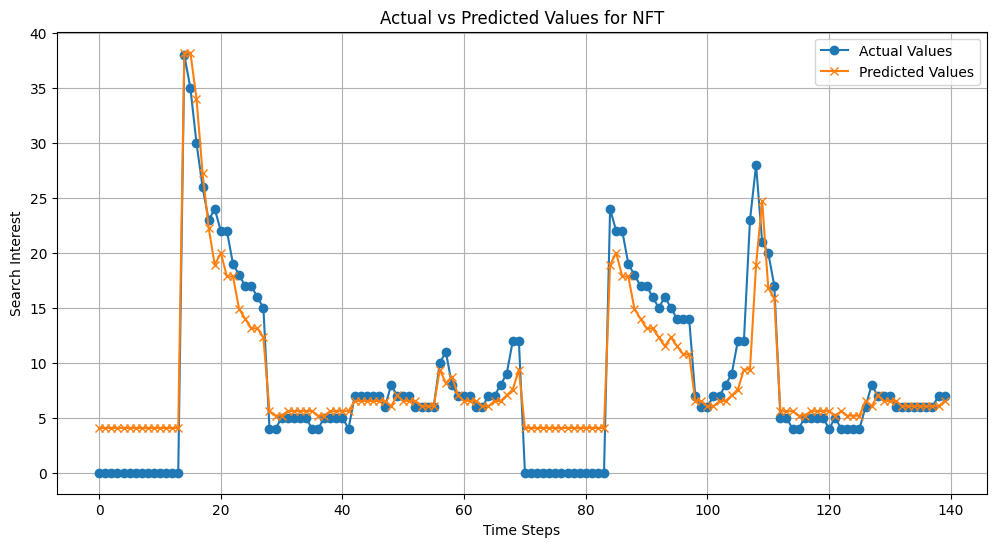

Processing keyword: NLP
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0852 - mae: 0.2706 - val_loss: 0.0727 - val_mae: 0.2492
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0675 - mae: 0.2366 - val_loss: 0.0502 - val_mae: 0.2015
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0440 - mae: 0.1838 - val_loss: 0.0159 - val_mae: 0.1122
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0136 - mae: 0.0994 - val_loss: 0.0078 - val_mae: 0.0675
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0094 - mae: 0.0784 - val_loss: 0.0076 - val_mae: 0.0688
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0086 - mae: 0.0770 - val_loss: 0.0076 - val_mae: 0.0685
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0088 - mae: 0.0775 - val_loss: 0.0075 - val_mae: 0.0685
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0081 - mae: 0.0750 - val_loss: 0.0074 - val_mae: 0.0673
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - mae: 0.0746 - 

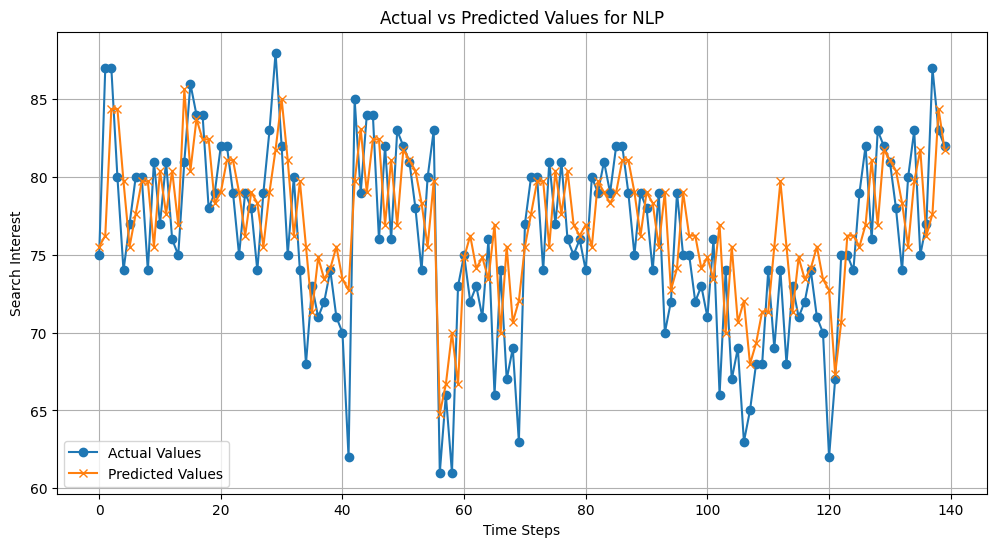

Processing keyword: Nano robotics
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1281 - mae: 0.2903 - val_loss: 0.1309 - val_mae: 0.2994
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1175 - mae: 0.2785 - val_loss: 0.1178 - val_mae: 0.2847
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1035 - mae: 0.2639 - val_loss: 0.1005 - val_mae: 0.2675
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0910 - mae: 0.2574 - val_loss: 0.0833 - val_mae: 0.2587
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0905 - mae: 0.2747 - val_loss: 0.0757 - val_mae: 0.2545
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0852 - mae: 0.2664 - val_loss: 0.0733 - val_mae: 0.2515
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0885 - mae: 0.2730 - val_loss: 0.0704 - val_mae: 0.2481
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0856 - mae: 0.2627 - val_loss: 0.0687 - val_mae: 0.2449
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0766 - mae: 0.2549 - v

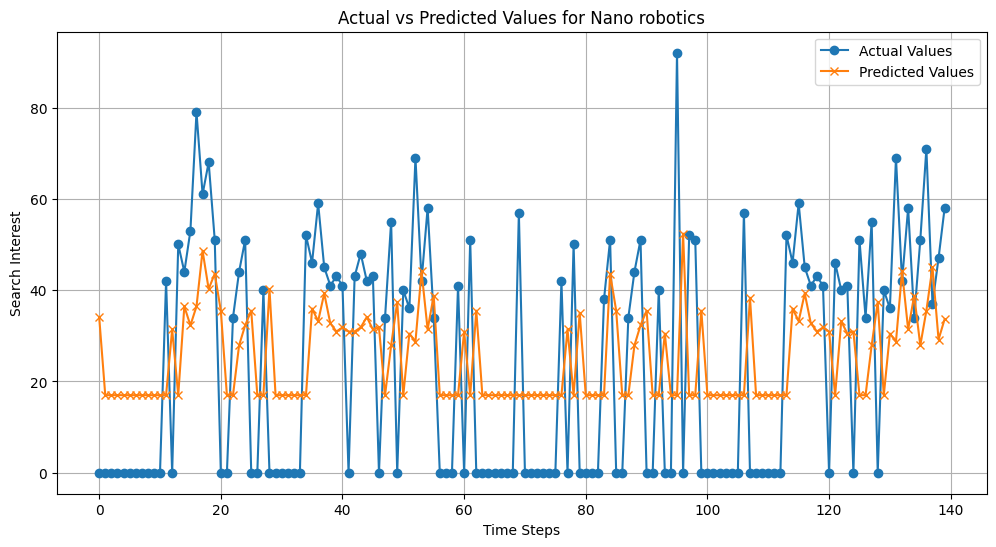

Processing keyword: Network Slicing
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0096 - mae: 0.0770 - val_loss: 0.0102 - val_mae: 0.0786
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 - mae: 0.0841 - val_loss: 0.0103 - val_mae: 0.0788
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 - mae: 0.0768 - val_loss: 0.0103 - val_mae: 0.0787
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0110 - mae: 0.0825 - val_loss: 0.0102 - val_mae: 0.0786
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0114 - mae: 0.0828 - val_loss: 0.0102 - val_mae: 0.0786
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124 - mae: 0.0846 - val_loss: 0.0102 - val_mae: 0.0785
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104 - mae: 0.0786 - val_loss: 0.0103 - val_mae: 0.0786
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0114 - mae: 0.0830 - val_loss: 0.0101 - val_mae: 0.0782
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143 - mae: 0.0865 - v

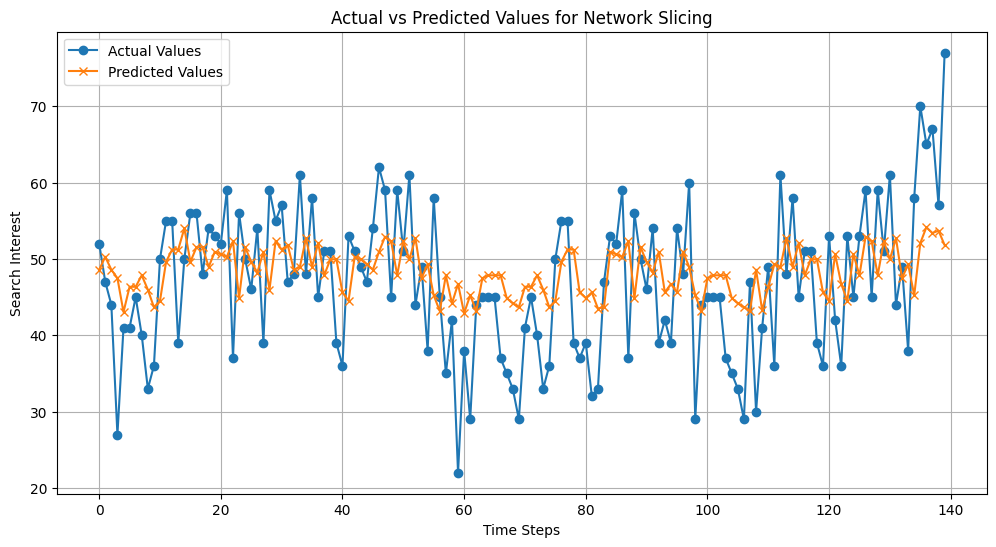

Processing keyword: Public Cloud
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0212 - mae: 0.1184 - val_loss: 0.0174 - val_mae: 0.1142
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0222 - mae: 0.1200 - val_loss: 0.0158 - val_mae: 0.1079
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 - mae: 0.1142 - val_loss: 0.0152 - val_mae: 0.1043
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.1069 - val_loss: 0.0148 - val_mae: 0.1031
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181 - mae: 0.1076 - val_loss: 0.0142 - val_mae: 0.1013
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0148 - mae: 0.0986 - val_loss: 0.0134 - val_mae: 0.0985
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0137 - mae: 0.0937 - val_loss: 0.0124 - val_mae: 0.0951
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0134 - mae: 0.0942 - val_loss: 0.0111 - val_mae: 0.0901
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126 - mae: 0.0906 - 

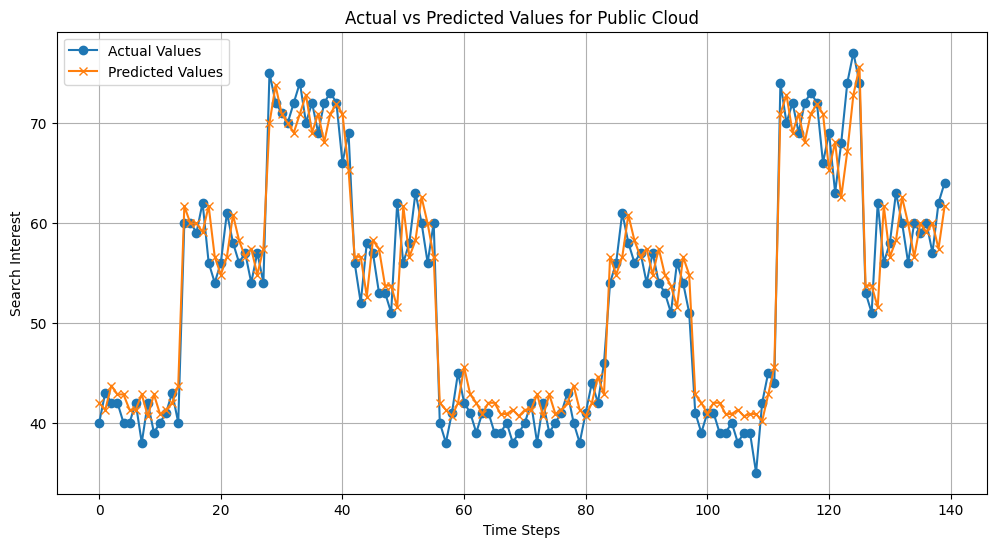

Processing keyword: Quantum Cryptography
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0468 - mae: 0.1895 - val_loss: 0.0435 - val_mae: 0.1800
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0473 - mae: 0.1897 - val_loss: 0.0345 - val_mae: 0.1596
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0337 - mae: 0.1532 - val_loss: 0.0230 - val_mae: 0.1304
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0264 - mae: 0.1329 - val_loss: 0.0168 - val_mae: 0.1118
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0254 - mae: 0.1249 - val_loss: 0.0151 - val_mae: 0.1056
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0228 - mae: 0.1171 - val_loss: 0.0141 - val_mae: 0.1017
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0230 - mae: 0.1201 - val_loss: 0.0126 - val_mae: 0.0958
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0197 - mae: 0.1081 - val_loss: 0.0109 - val_mae: 0.0886
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0174 - mae: 0.1025 - v

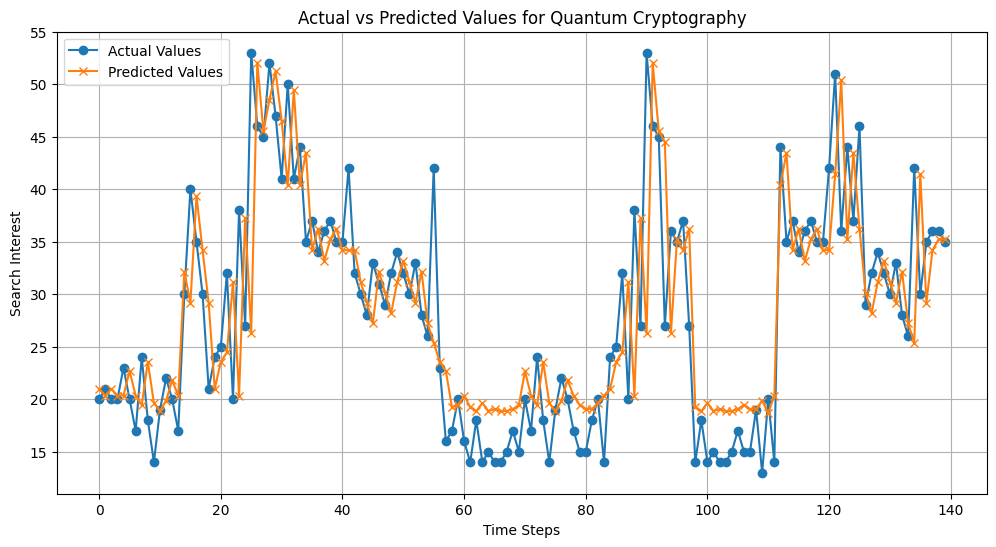

Processing keyword: Quantum computing
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.1188 - mae: 0.3392 - val_loss: 0.1108 - val_mae: 0.3312
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1045 - mae: 0.3171 - val_loss: 0.0882 - val_mae: 0.2950
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0816 - mae: 0.2775 - val_loss: 0.0503 - val_mae: 0.2214
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0476 - mae: 0.2023 - val_loss: 0.0144 - val_mae: 0.1137
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0319 - mae: 0.1230 - val_loss: 0.0032 - val_mae: 0.0480
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0185 - mae: 0.0753 - val_loss: 0.0022 - val_mae: 0.0387
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0218 - mae: 0.0725 - val_loss: 0.0024 - val_mae: 0.0409
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0146 - mae: 0.0693 - val_loss: 0.0024 - val_mae: 0.0404
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0217 - mae: 0.0783 - 

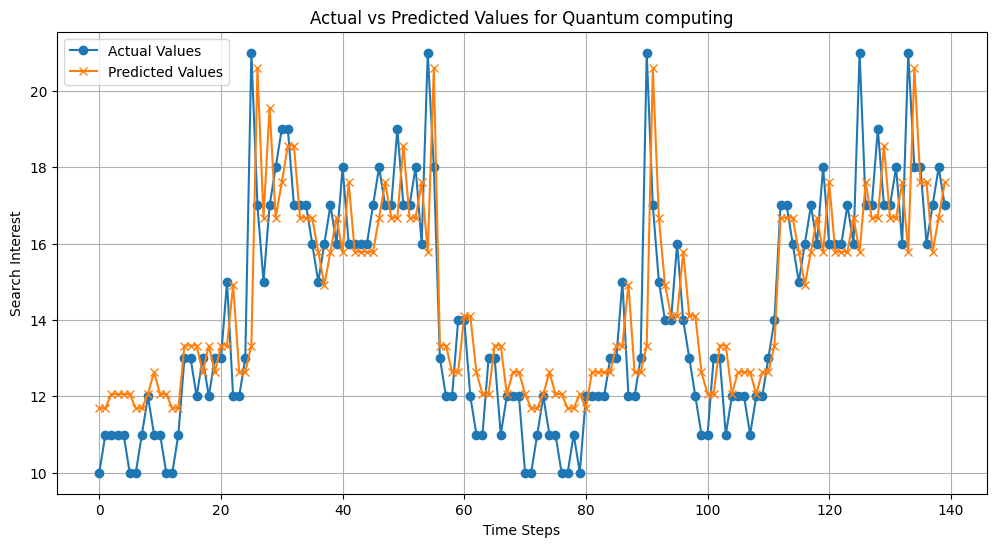

Processing keyword: Qubits
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1059 - mae: 0.3152 - val_loss: 0.1013 - val_mae: 0.3130
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0938 - mae: 0.2957 - val_loss: 0.0768 - val_mae: 0.2708
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0612 - mae: 0.2321 - val_loss: 0.0364 - val_mae: 0.1799
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0342 - mae: 0.1597 - val_loss: 0.0084 - val_mae: 0.0750
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0153 - mae: 0.0910 - val_loss: 0.0052 - val_mae: 0.0616
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0142 - mae: 0.0779 - val_loss: 0.0050 - val_mae: 0.0602
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0152 - mae: 0.0838 - val_loss: 0.0048 - val_mae: 0.0587
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 - mae: 0.0701 - val_loss: 0.0043 - val_mae: 0.0561
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0100 - mae: 0.0717 - v

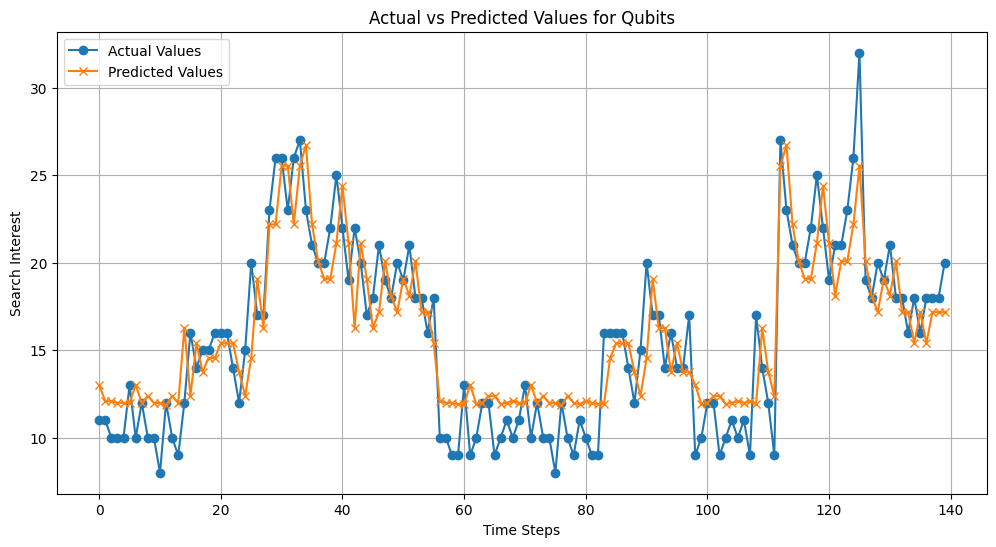

Processing keyword: RPA Software
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0239 - mae: 0.1256 - val_loss: 0.0198 - val_mae: 0.1180
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0210 - mae: 0.1162 - val_loss: 0.0132 - val_mae: 0.0904
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0159 - mae: 0.0975 - val_loss: 0.0089 - val_mae: 0.0712
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0160 - mae: 0.0982 - val_loss: 0.0087 - val_mae: 0.0701
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 - mae: 0.0954 - val_loss: 0.0088 - val_mae: 0.0707
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 - mae: 0.1001 - val_loss: 0.0087 - val_mae: 0.0703
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 - mae: 0.0969 - val_loss: 0.0086 - val_mae: 0.0694
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0138 - mae: 0.0944 - val_loss: 0.0087 - val_mae: 0.0703
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0152 - mae: 0.0964 - v

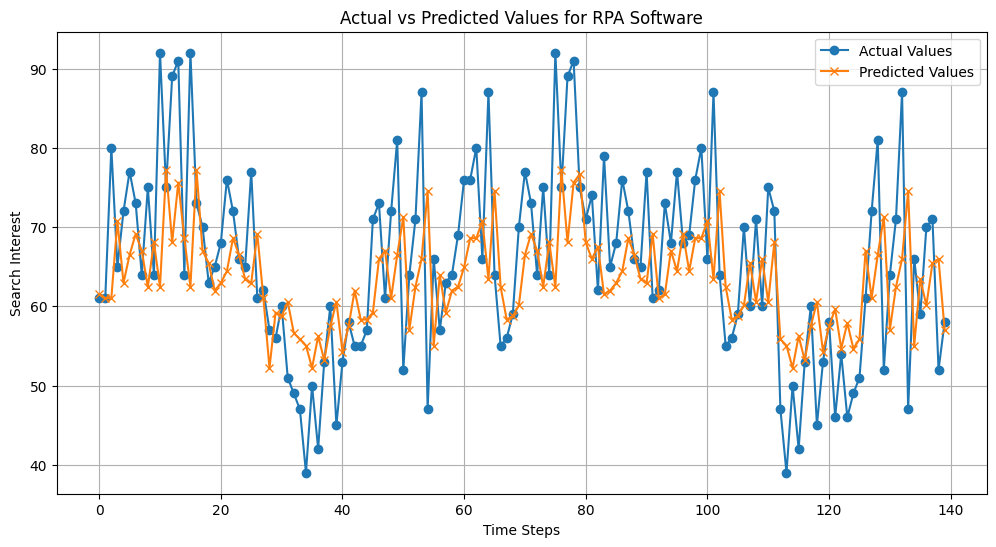

Processing keyword: Reinforcement Learning
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0357 - mae: 0.1567 - val_loss: 0.0281 - val_mae: 0.1491
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0309 - mae: 0.1501 - val_loss: 0.0223 - val_mae: 0.1351
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0271 - mae: 0.1471 - val_loss: 0.0198 - val_mae: 0.1211
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0225 - mae: 0.1313 - val_loss: 0.0194 - val_mae: 0.1177
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0225 - mae: 0.1290 - val_loss: 0.0184 - val_mae: 0.1146
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0208 - mae: 0.1255 - val_loss: 0.0173 - val_mae: 0.1106
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0184 - mae: 0.1172 - val_loss: 0.0161 - val_mae: 0.1059
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0176 - mae: 0.1143 - val_loss: 0.0144 - val_mae: 0.1005
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163 - mae: 0.1085 - v

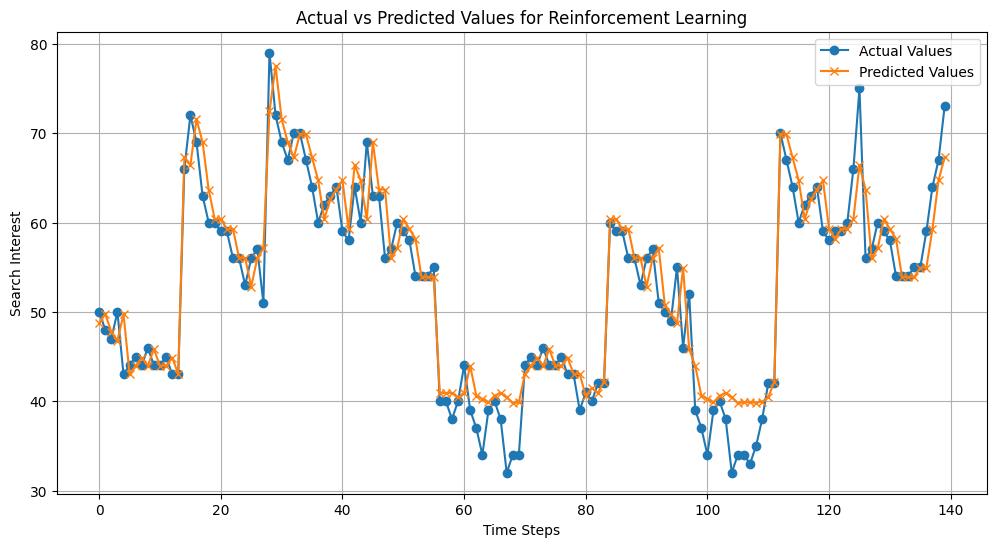

Processing keyword: Reusable Rockets
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1559 - mae: 0.3785 - val_loss: 0.1457 - val_mae: 0.3691
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1507 - mae: 0.3729 - val_loss: 0.1194 - val_mae: 0.3304
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1142 - mae: 0.3186 - val_loss: 0.0763 - val_mae: 0.2518
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0622 - mae: 0.2237 - val_loss: 0.0367 - val_mae: 0.1402
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0283 - mae: 0.1329 - val_loss: 0.0257 - val_mae: 0.1033
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0216 - mae: 0.1087 - val_loss: 0.0251 - val_mae: 0.1041
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0227 - mae: 0.1143 - val_loss: 0.0250 - val_mae: 0.1056
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0210 - mae: 0.1128 - val_loss: 0.0250 - val_mae: 0.1063
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184 - mae: 0.1095 

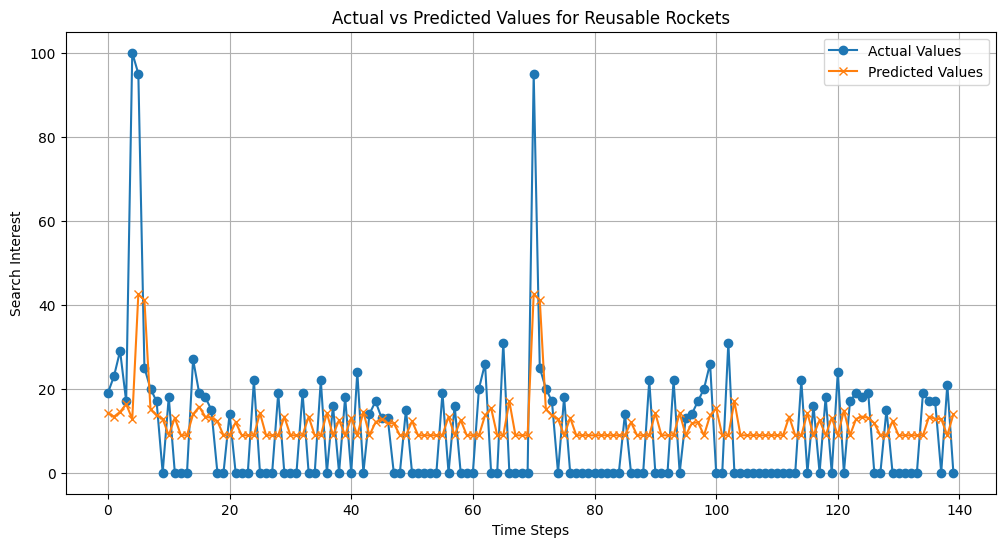

Processing keyword: Small Satellites
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0556 - mae: 0.2096 - val_loss: 0.0489 - val_mae: 0.1993
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0460 - mae: 0.1889 - val_loss: 0.0341 - val_mae: 0.1569
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0317 - mae: 0.1482 - val_loss: 0.0159 - val_mae: 0.1039
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0234 - mae: 0.1121 - val_loss: 0.0111 - val_mae: 0.0879
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0152 - mae: 0.0950 - val_loss: 0.0113 - val_mae: 0.0892
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0212 - mae: 0.1077 - val_loss: 0.0111 - val_mae: 0.0884
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0155 - mae: 0.0958 - val_loss: 0.0106 - val_mae: 0.0863
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0164 - mae: 0.0927 - val_loss: 0.0106 - val_mae: 0.0862
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0191 - mae: 0.1003 - v

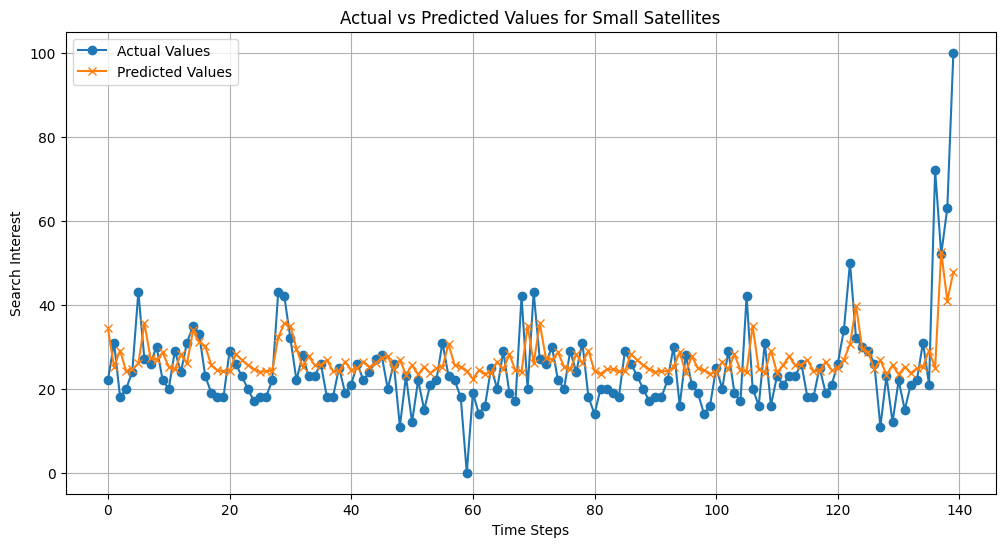

Processing keyword: Smart Contracts
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0920 - mae: 0.2939 - val_loss: 0.0840 - val_mae: 0.2778
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0814 - mae: 0.2741 - val_loss: 0.0680 - val_mae: 0.2466
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0633 - mae: 0.2387 - val_loss: 0.0410 - val_mae: 0.1836
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0357 - mae: 0.1686 - val_loss: 0.0177 - val_mae: 0.1069
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0202 - mae: 0.1056 - val_loss: 0.0147 - val_mae: 0.0868
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - mae: 0.0794 - val_loss: 0.0143 - val_mae: 0.0842
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0178 - mae: 0.0886 - val_loss: 0.0139 - val_mae: 0.0841
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0134 - mae: 0.0836 - val_loss: 0.0134 - val_mae: 0.0818
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0160 - mae: 0.0836 - v

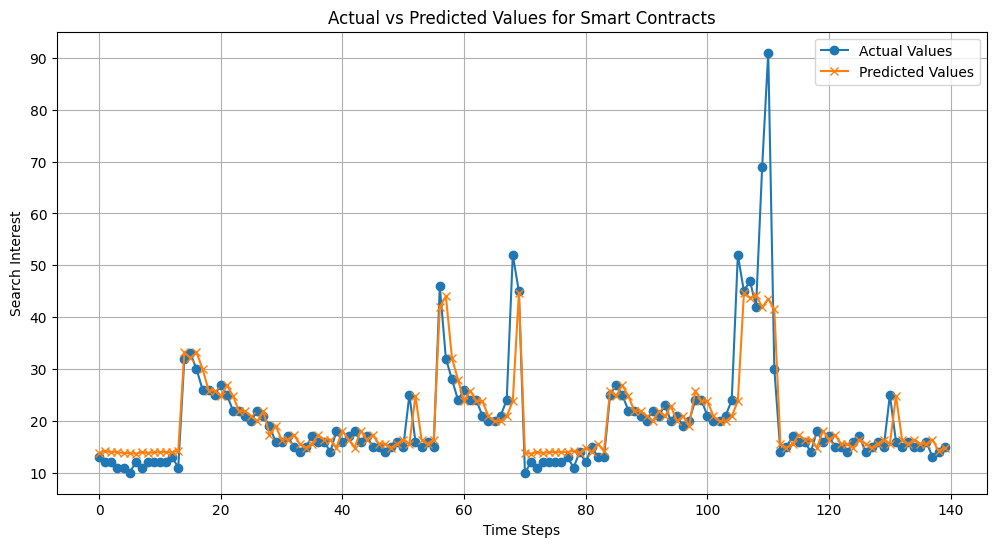

Processing keyword: Smart Sensors
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0340 - mae: 0.1518 - val_loss: 0.0128 - val_mae: 0.0942
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0299 - mae: 0.1390 - val_loss: 0.0090 - val_mae: 0.0763
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0226 - mae: 0.1187 - val_loss: 0.0062 - val_mae: 0.0609
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0121 - mae: 0.0862 - val_loss: 0.0096 - val_mae: 0.0784
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110 - mae: 0.0854 - val_loss: 0.0084 - val_mae: 0.0714
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0110 - mae: 0.0854 - val_loss: 0.0084 - val_mae: 0.0716
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0106 - mae: 0.0831 - val_loss: 0.0087 - val_mae: 0.0732
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0103 - mae: 0.0825 - val_loss: 0.0081 - val_mae: 0.0700
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 - mae: 0.0815 - 

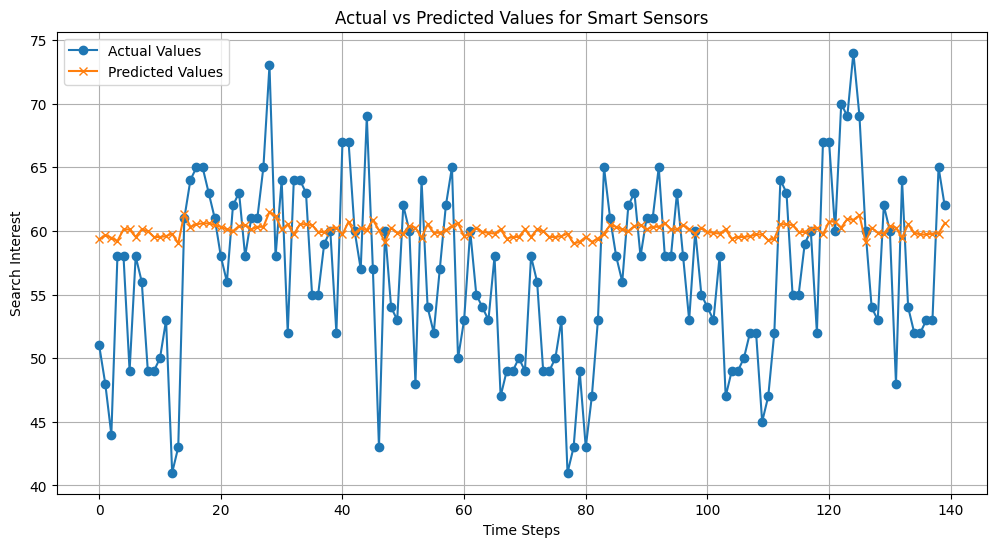

Processing keyword: Smart grid and IoT
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2290 - mae: 0.4663 - val_loss: 0.2187 - val_mae: 0.4560
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2166 - mae: 0.4556 - val_loss: 0.2009 - val_mae: 0.4386
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1951 - mae: 0.4346 - val_loss: 0.1686 - val_mae: 0.4040
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1555 - mae: 0.3886 - val_loss: 0.1148 - val_mae: 0.3335
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0990 - mae: 0.3071 - val_loss: 0.0646 - val_mae: 0.2313
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0503 - mae: 0.2011 - val_loss: 0.0487 - val_mae: 0.1575
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0477 - mae: 0.1494 - val_loss: 0.0475 - val_mae: 0.1337
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0340 - mae: 0.1165 - val_loss: 0.0476 - val_mae: 0.1207
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0418 - mae: 0.1155

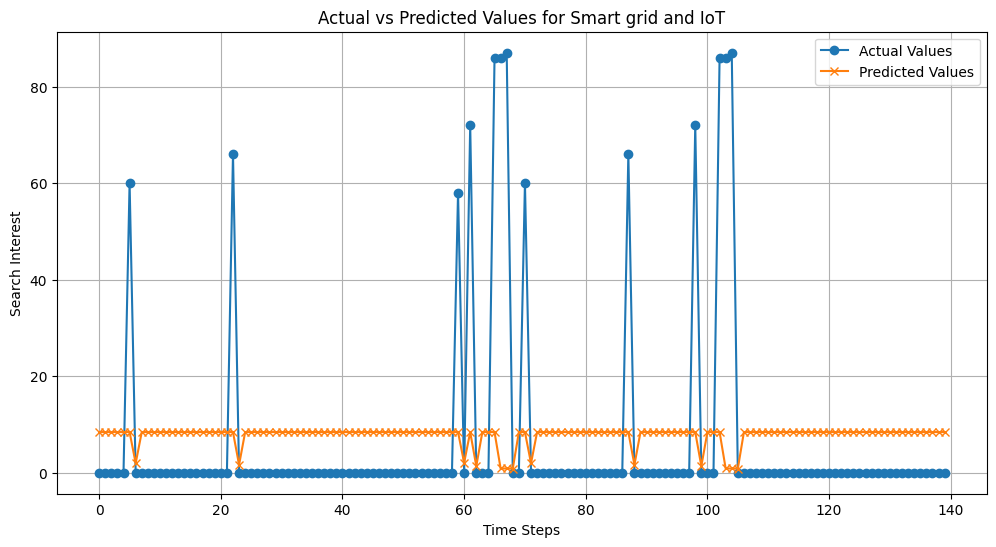

Processing keyword: Super Apps
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1124 - mae: 0.3305 - val_loss: 0.1078 - val_mae: 0.3276
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0972 - mae: 0.3069 - val_loss: 0.0835 - val_mae: 0.2882
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0732 - mae: 0.2650 - val_loss: 0.0422 - val_mae: 0.2041
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0348 - mae: 0.1709 - val_loss: 0.0072 - val_mae: 0.0814
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163 - mae: 0.0827 - val_loss: 0.0012 - val_mae: 0.0270
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0141 - mae: 0.0585 - val_loss: 0.0014 - val_mae: 0.0297
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0162 - mae: 0.0640 - val_loss: 0.0015 - val_mae: 0.0311
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0196 - mae: 0.0702 - val_loss: 0.0015 - val_mae: 0.0313
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0128 - mae: 0.0607 - v

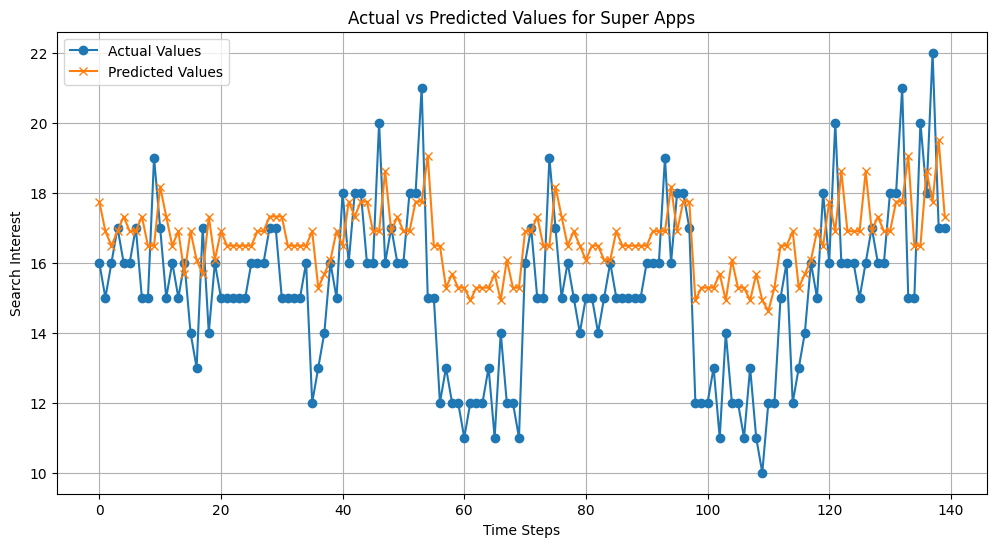

Processing keyword: Synthetic Data
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0430 - mae: 0.1775 - val_loss: 0.0409 - val_mae: 0.1748
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0426 - mae: 0.1782 - val_loss: 0.0372 - val_mae: 0.1654
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0383 - mae: 0.1676 - val_loss: 0.0333 - val_mae: 0.1550
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0340 - mae: 0.1542 - val_loss: 0.0296 - val_mae: 0.1451
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0303 - mae: 0.1462 - val_loss: 0.0243 - val_mae: 0.1314
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0265 - mae: 0.1378 - val_loss: 0.0167 - val_mae: 0.1102
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0178 - mae: 0.1123 - val_loss: 0.0085 - val_mae: 0.0786
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - mae: 0.0756 - val_loss: 0.0033 - val_mae: 0.0466
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 - mae: 0.0581 - v

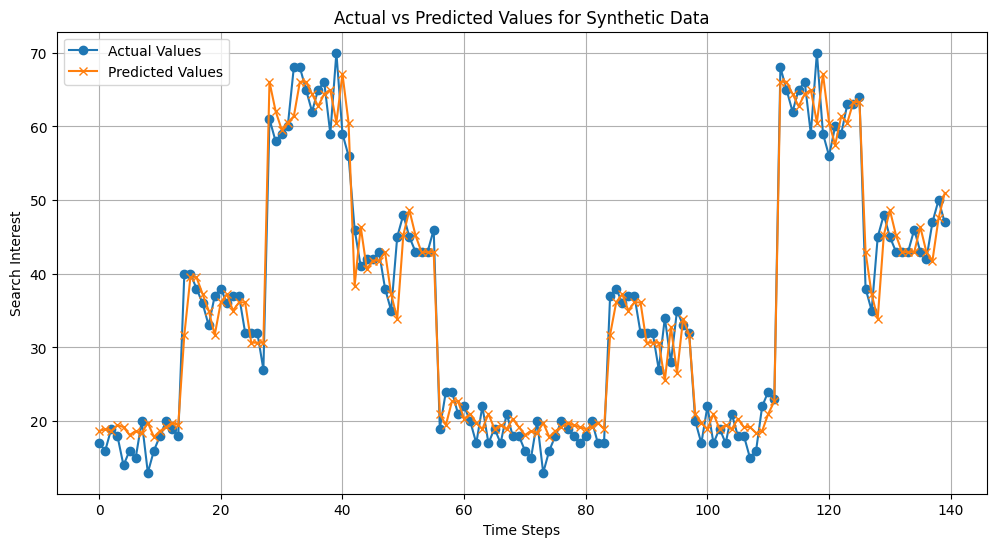

Processing keyword: Telemedicine
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0940 - mae: 0.3051 - val_loss: 0.0855 - val_mae: 0.2833
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0819 - mae: 0.2844 - val_loss: 0.0672 - val_mae: 0.2483
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0566 - mae: 0.2351 - val_loss: 0.0404 - val_mae: 0.1797
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0214 - mae: 0.1383 - val_loss: 0.0281 - val_mae: 0.0984
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 - mae: 0.0408 - val_loss: 0.0299 - val_mae: 0.0781
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020 - mae: 0.0335 - val_loss: 0.0298 - val_mae: 0.0779
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - mae: 0.0362 - val_loss: 0.0295 - val_mae: 0.0783
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - mae: 0.0398 - val_loss: 0.0292 - val_mae: 0.0785
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0358 - v

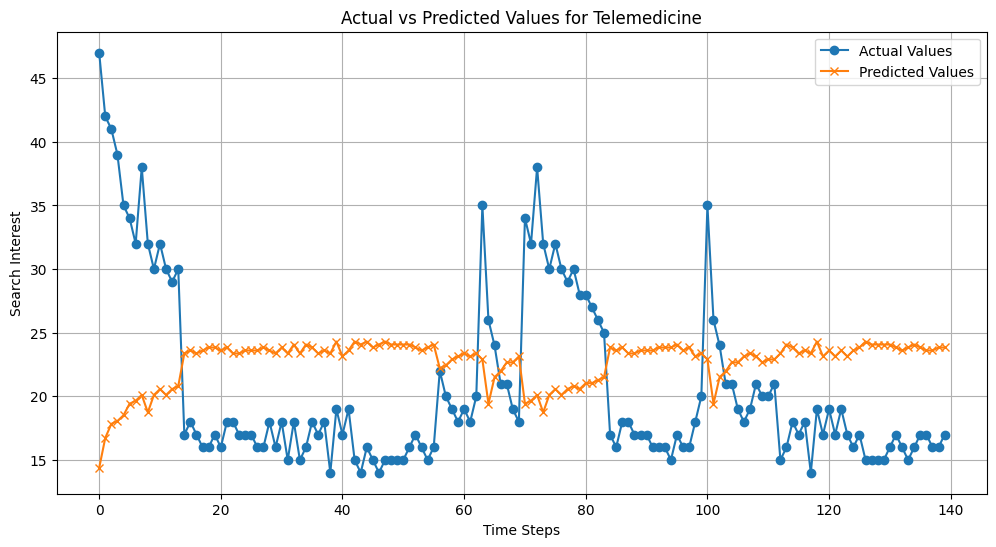

Processing keyword: V2X
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0355 - mae: 0.1513 - val_loss: 0.0330 - val_mae: 0.1581
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0363 - mae: 0.1558 - val_loss: 0.0323 - val_mae: 0.1577
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0349 - mae: 0.1591 - val_loss: 0.0316 - val_mae: 0.1567
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0314 - mae: 0.1508 - val_loss: 0.0306 - val_mae: 0.1536
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0325 - mae: 0.1610 - val_loss: 0.0279 - val_mae: 0.1465
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0258 - mae: 0.1428 - val_loss: 0.0244 - val_mae: 0.1365
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0227 - mae: 0.1340 - val_loss: 0.0188 - val_mae: 0.1193
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0175 - mae: 0.1167 - val_loss: 0.0132 - val_mae: 0.0975
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0113 - mae: 0.0904 - v

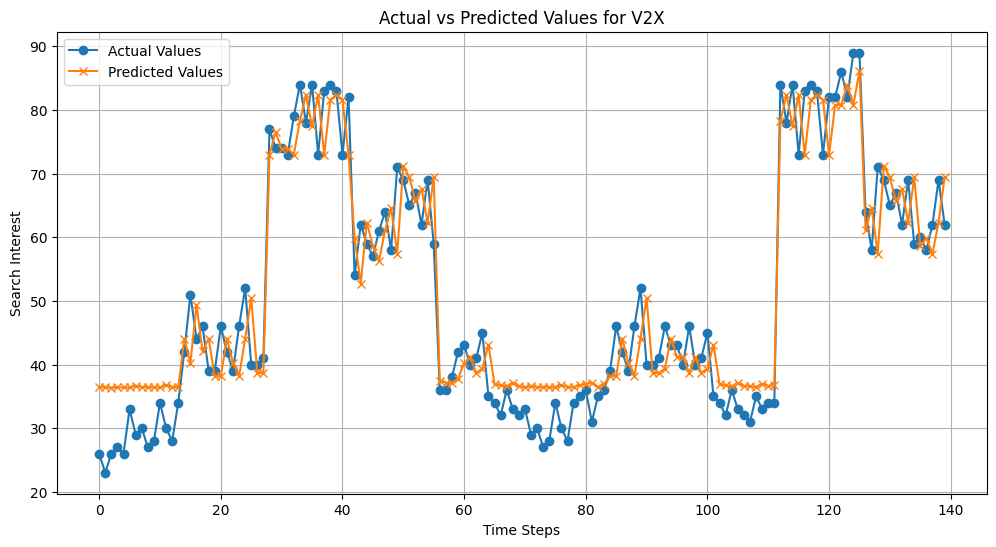

Processing keyword: VR Headsets
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0245 - mae: 0.1388 - val_loss: 0.0345 - val_mae: 0.1781
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0210 - mae: 0.1284 - val_loss: 0.0240 - val_mae: 0.1463
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0160 - mae: 0.1055 - val_loss: 0.0140 - val_mae: 0.1096
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - mae: 0.0956 - val_loss: 0.0121 - val_mae: 0.1014
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - mae: 0.0886 - val_loss: 0.0122 - val_mae: 0.1018
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0117 - mae: 0.0859 - val_loss: 0.0116 - val_mae: 0.0995
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0123 - mae: 0.0866 - val_loss: 0.0114 - val_mae: 0.0986
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0125 - mae: 0.0845 - val_loss: 0.0110 - val_mae: 0.0968
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0133 - mae: 0.0866 -

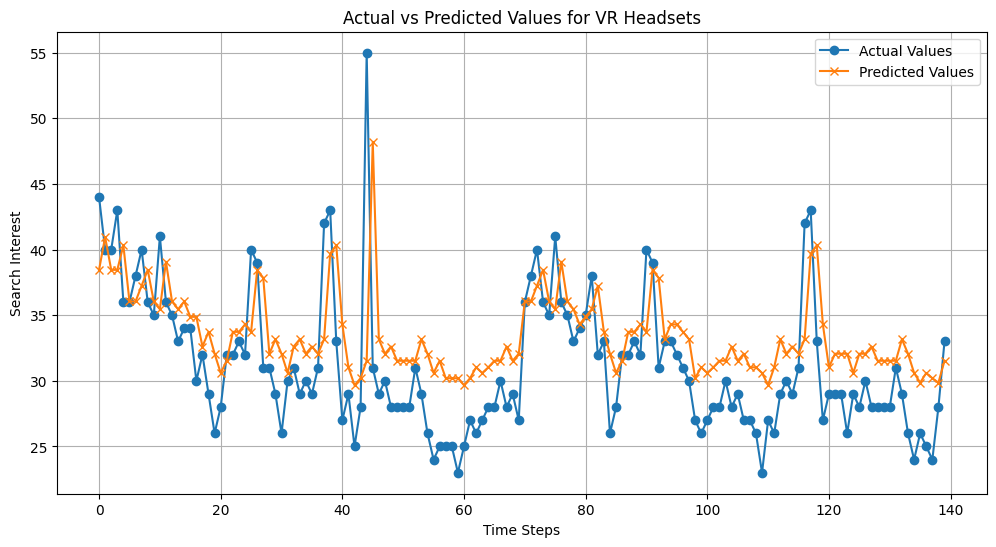

Processing keyword: Vertical Farming
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0433 - mae: 0.1853 - val_loss: 0.0334 - val_mae: 0.1633
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0334 - mae: 0.1606 - val_loss: 0.0209 - val_mae: 0.1214
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0211 - mae: 0.1193 - val_loss: 0.0068 - val_mae: 0.0638
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088 - mae: 0.0733 - val_loss: 0.0059 - val_mae: 0.0628
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0099 - mae: 0.0763 - val_loss: 0.0056 - val_mae: 0.0603
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0089 - mae: 0.0749 - val_loss: 0.0056 - val_mae: 0.0606
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - mae: 0.0725 - val_loss: 0.0056 - val_mae: 0.0604
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0089 - mae: 0.0745 - val_loss: 0.0055 - val_mae: 0.0593
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0088 - mae: 0.0738 -

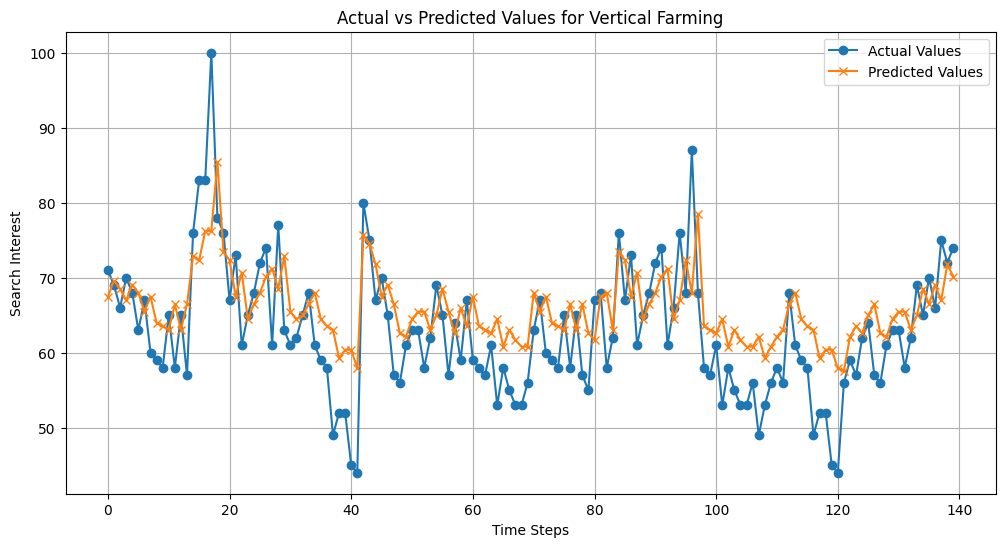

Processing keyword: Virtual reality technology
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0328 - mae: 0.1533 - val_loss: 0.0250 - val_mae: 0.1352
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 - mae: 0.1317 - val_loss: 0.0203 - val_mae: 0.1185
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0228 - mae: 0.1173 - val_loss: 0.0171 - val_mae: 0.1067
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0215 - mae: 0.1058 - val_loss: 0.0159 - val_mae: 0.1034
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0209 - mae: 0.1058 - val_loss: 0.0150 - val_mae: 0.1003
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.0983 - val_loss: 0.0140 - val_mae: 0.0971
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0172 - mae: 0.0956 - val_loss: 0.0124 - val_mae: 0.0916
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0178 - mae: 0.0975 - val_loss: 0.0104 - val_mae: 0.0838
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0153 - mae: 0.0906 - v

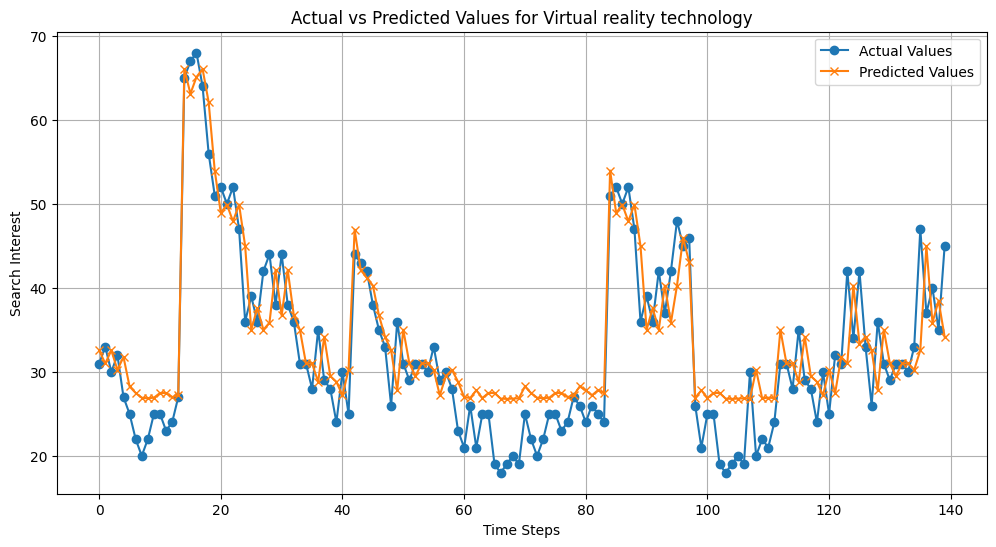

Processing keyword: Zero Trust
All windows sorted by time:
Train size: 40, Test size: 10
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0322 - mae: 0.1455 - val_loss: 0.0287 - val_mae: 0.1354
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0310 - mae: 0.1441 - val_loss: 0.0266 - val_mae: 0.1326
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0267 - mae: 0.1325 - val_loss: 0.0244 - val_mae: 0.1301
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0248 - mae: 0.1300 - val_loss: 0.0216 - val_mae: 0.1236
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0220 - mae: 0.1220 - val_loss: 0.0170 - val_mae: 0.1086
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0169 - mae: 0.1068 - val_loss: 0.0105 - val_mae: 0.0862
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0099 - mae: 0.0773 - val_loss: 0.0046 - val_mae: 0.0553
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - mae: 0.0605 - val_loss: 0.0022 - val_mae: 0.0360
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043 - mae: 0.049

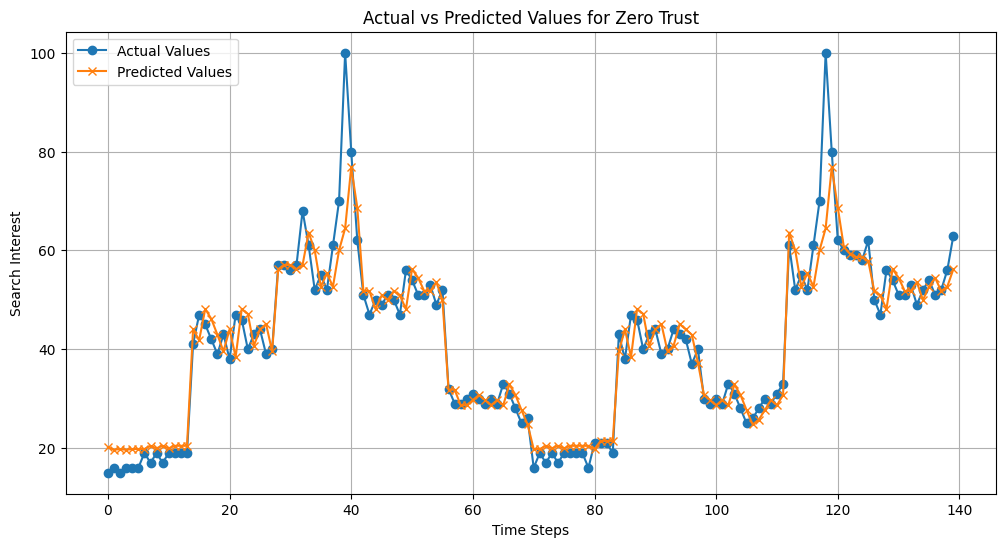

                       Keyword  Test Loss  Test MAE        MAE          MAPE  \
0                  AI Security   0.000583  0.017730   1.772972  1.411660e-01   
1                   AR Glasses   0.004514  0.034773   3.477327  1.513481e-01   
2            Adaptive learning   0.002663  0.041450   4.145048  1.014370e-01   
3                   Applied AI   0.001264  0.027658   2.765849  9.956942e-02   
4            Augmented reality   0.003637  0.039597   3.959677  6.535255e-02   
5                  Bioprinting   0.009953  0.061624   6.162391  1.437599e-01   
6                       CRISPR   0.002098  0.037640   3.764030  1.205576e-01   
7               Carbon Capture   0.002752  0.035639   3.563852  3.365102e-01   
8             Cashless Payment   0.009389  0.065598   6.559781  1.466566e-01   
9                     Chatbots   0.001069  0.024381   2.438081  6.679043e-02   
10     Cloud computing for IoT   0.029044  0.127144  12.714389  5.998083e+10   
11   Cloud computing platforms   0.02406

In [ ]:
#CHẠY TỪNG KEYWORDS
# Tạo một dictionary để lưu trữ kết quả đánh giá cho từng keyword
results = {
    'Keyword': [],
    'Test Loss': [],
    'Test MAE': [],
    'MAE': [],
    'MAPE': [],
    'RMSE': [],
    'R²': []
}

for keyword, windows in sliding_windows.items():
    print(f"Processing keyword: {keyword}")

    # Chia dữ liệu thành tập huấn luyện và tập kiểm tra theo thời gian
    train_windows, test_windows = split_train_test_fixed(windows)

    # Chuẩn bị dữ liệu cho LSTM
    X_train, y_train = prepare_data_for_lstm(train_windows, n_steps_in, n_steps_out)
    X_test, y_test = prepare_data_for_lstm(test_windows, n_steps_in, n_steps_out)

    # Reshape dữ liệu để phù hợp với LSTM (samples, timesteps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Xây dựng mô hình LSTM
    input_shape = (X_train.shape[1], 1)  # (timesteps, features)
    model = build_lstm_model(input_shape, n_steps_out, optimizer=optimizer, loss=loss)

    # Huấn luyện mô hình với Early Stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=0.2, callbacks=[early_stopping], verbose=1)

    # Đánh giá mô hình trên tập kiểm tra
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test loss for {keyword}: {test_loss}")
    print(f"Test MAE for {keyword}: {test_mae}")

    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)

    # Chuyển đổi ngược lại (inverse transform) các giá trị dự đoán về phạm vi ban đầu
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Tính các chỉ số đánh giá
    mae, mape, rmse, r2 = evaluate_model(y_test_original.flatten(), y_pred_original.flatten())
    print(f"MAE for {keyword}: {mae}")
    print(f"MAPE for {keyword}: {mape}")
    print(f"RMSE for {keyword}: {rmse}")
    print(f"R² for {keyword}: {r2}")
    print("\n")

    # Lưu trữ kết quả đánh giá vào dictionary
    results['Keyword'].append(keyword)
    results['Test Loss'].append(test_loss)
    results['Test MAE'].append(test_mae)
    results['MAE'].append(mae)
    results['MAPE'].append(mape)
    results['RMSE'].append(rmse)
    results['R²'].append(r2)

    # Vẽ đồ thị so sánh giá trị thực tế và giá trị dự đoán
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original.flatten(), label='Actual Values', marker='o')
    plt.plot(y_pred_original.flatten(), label='Predicted Values', marker='x')
    plt.title(f'Actual vs Predicted Values for {keyword}')
    plt.xlabel('Time Steps')
    plt.ylabel('Search Interest')
    plt.legend()
    plt.grid(True)
    plt.show()

# Chuyển dictionary thành DataFrame
results_df = pd.DataFrame(results)

# In ra bảng thống kê
print(results_df)

# Lưu bảng thống kê vào file CSV (tuỳ chọn)
results_df.to_csv('/content/evaluation_results_batchsz16.csv')

Training model on all data...
Epoch 1/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0459 - mae: 0.1470 - val_loss: 0.0114 - val_mae: 0.0568
Epoch 2/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0139 - mae: 0.0785 - val_loss: 0.0113 - val_mae: 0.0569
Epoch 3/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0135 - mae: 0.0772 - val_loss: 0.0111 - val_mae: 0.0564
Epoch 4/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0130 - mae: 0.0758 - val_loss: 0.0111 - val_mae: 0.0564
Epoch 5/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0129 - mae: 0.0746 - val_loss: 0.0111 - val_mae: 0.0568
Epoch 6/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0129 - mae: 0.0745 - val_loss: 0.0111 - val_mae: 0.0576
Epoch 7/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0128 - mae: 0.0748 - val_loss: 0.0111 - val_mae: 0.0569
Epoch 8/50
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0123 - mae: 0.0739 - val_loss: 0.0110 - val_mae: 0.0569
Epoch 9

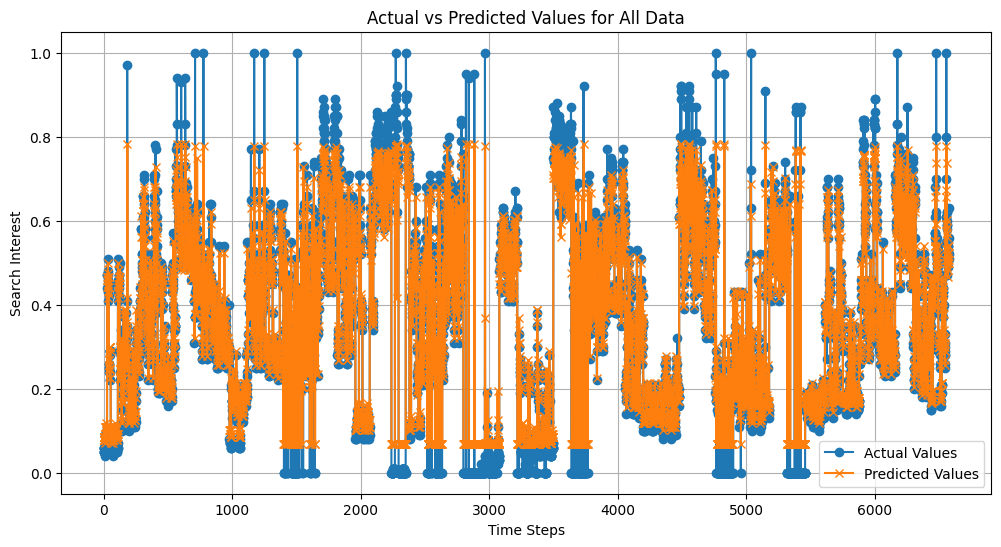

In [ ]:
# CHẠY TỔNG THỂ MÔ HÌNH
# Tổng hợp các window train và test từ tất cả các keyword
all_train_windows = []
all_test_windows = []

for keyword, windows in sliding_windows.items():
    train_windows, test_windows = split_train_test_fixed(windows)
    all_train_windows.extend(train_windows)
    all_test_windows.extend(test_windows)

# Chuẩn bị dữ liệu cho LSTM từ tập tổng hợp
X_train_all, y_train_all = prepare_data_for_lstm(all_train_windows, n_steps_in, n_steps_out)
X_test_all, y_test_all = prepare_data_for_lstm(all_test_windows, n_steps_in, n_steps_out)

# Reshape dữ liệu để phù hợp với LSTM (samples, timesteps, features)
X_train_all = X_train_all.reshape((X_train_all.shape[0], X_train_all.shape[1], 1))
X_test_all = X_test_all.reshape((X_test_all.shape[0], X_test_all.shape[1], 1))

# Xây dựng mô hình LSTM
input_shape = (X_train_all.shape[1], 1)  # (timesteps, features)
model_all = build_lstm_model(input_shape, n_steps_out, optimizer=optimizer, loss=loss)

# Huấn luyện mô hình trên tập tổng hợp với Early Stopping
print("Training model on all data...")
history_all = model_all.fit(X_train_all, y_train_all, epochs=epochs, batch_size=batch_size,
                            validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Đánh giá mô hình trên tập kiểm tra tổng hợp
test_loss_all, test_mae_all = model_all.evaluate(X_test_all, y_test_all, verbose=0)
print(f"Test loss for all data: {test_loss_all}")
print(f"Test MAE for all data: {test_mae_all}")

# Dự đoán trên tập kiểm tra tổng hợp
y_pred_all = model_all.predict(X_test_all)

# Chuyển đổi ngược lại (inverse transform) các giá trị dự đoán về phạm vi ban đầu
y_pred_all_original = scaler.inverse_transform(y_pred_all.reshape(-1, 1))
y_test_all_original = scaler.inverse_transform(y_test_all.reshape(-1, 1))

# Tính các chỉ số đánh giá trên tập tổng hợp
mae_all, mape_all, rmse_all, r2_all = evaluate_model(y_test_all_original.flatten(), y_pred_all_original.flatten())
print(f"MAE for all data: {mae_all}")
print(f"MAPE for all data: {mape_all}")
print(f"RMSE for all data: {rmse_all}")
print(f"R² for all data: {r2_all}")
print("\n")

# Vẽ đồ thị so sánh giá trị thực tế và giá trị dự đoán trên tập tổng hợp
plt.figure(figsize=(12, 6))
plt.plot(y_test_all_original.flatten(), label='Actual Values', marker='o')
plt.plot(y_pred_all_original.flatten(), label='Predicted Values', marker='x')
plt.title('Actual vs Predicted Values for All Data')
plt.xlabel('Time Steps')
plt.ylabel('Search Interest')
plt.legend()
plt.grid(True)
plt.show()